## aai-511-final-project-group1


## Project Setup

In [1]:
# Install required libraries
# Install required library for MIDI processing
%pip install pretty_midi
# Install kagglehub for dataset download
%pip install kagglehub -q
# Install tensorflow
%pip install tensorflow --force-reinstall --no-cache-dir
dbutils.library.restartPython()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 253.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 376.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 359.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 266.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 338.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 381.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 405.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 366.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 372.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 382.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/7

NameError: name 'dbutils' is not defined

In [1]:
import kagglehub
import os
import zipfile
import shutil
import pretty_midi
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pretty_midi
import random
import tensorflow as tf

from sklearn.model_selection import train_test_split
from collections import Counter
from collections import defaultdict
from pathlib import Path
from datetime import datetime
from keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from scipy.ndimage import zoom
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers
import time

## 1. Data Collection:

Data is collected and provided to you.



In [ ]:
print("="*80)
print("DOWNLOADING MIDI CLASSIC MUSIC DATASET FROM KAGGLE")
print("="*80)

# Download latest version of the dataset
print("\nDownloading dataset from Kaggle...")
path = kagglehub.dataset_download("blanderbuss/midi-classic-music")

print(f"\n[OK] Dataset downloaded successfully!")
print(f"Path to dataset files: {path}")

# Set the dataset path for later use
dataset_path = path

# List all files and directories in the dataset path
print(f"\nExploring dataset structure...")
print("="*80)

try:
    # List items in the dataset directory
    items = os.listdir(dataset_path)
    print(f"\nFound {len(items)} items in the dataset directory:\n")

    for item in sorted(items)[:15]:
        item_path = os.path.join(dataset_path, item)
        item_type = "DIR" if os.path.isdir(item_path) else "FILE"
        print(f"[{item_type}] {item}")

    if len(items) > 15:
        print(f"\n... and {len(items) - 15} more items")

except Exception as e:
    print(f"Error accessing dataset: {e}")

print("\n" + "="*80)


In [ ]:
# Explore midiclassics.zip file - 4 Composers
print("="*80)
print("EXPLORING MIDICLASSICS.ZIP FILE")
print("="*80)

# Define the 4 composers we want to find
target_composers = ['bach', 'beethoven', 'chopin', 'mozart']

print(f"\nTarget composers: {', '.join([c.title() for c in target_composers])}")

# Look for midiclassics.zip in the dataset path
zip_file_path = os.path.join(dataset_path, 'midiclassics.zip')

print(f"\nLooking for zip file at: {zip_file_path}")

if not os.path.exists(zip_file_path):
    print(f"\n[X] midiclassics.zip not found at {zip_file_path}")
    print("\nSearching for zip files in dataset directory...")

    # Search for any zip files
    zip_files = [f for f in os.listdir(dataset_path) if f.endswith('.zip')]

    if zip_files:
        print(f"\nFound {len(zip_files)} zip file(s):")
        for zf in zip_files:
            print(f"• {zf}")

        # Use the first zip file found
        zip_file_path = os.path.join(dataset_path, zip_files[0])
        print(f"\nUsing: {zip_files[0]}")
    else:
        print("\n[X] No zip files found in dataset directory")
        raise FileNotFoundError("midiclassics.zip not found")

print("\n" + "="*80)
print("ANALYZING ZIP FILE CONTENTS")
print("="*80)

# Explore the zip file contents
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    # Get all file names in the zip
    all_files = zip_ref.namelist()

    print(f"\nTotal files in zip: {len(all_files)}")

    # Organize files by composer
    composer_files = defaultdict(list)
    all_composers_found = set()

    for file_path in all_files:
        # Skip directories
        if file_path.endswith('/'):
            continue

        # Check if it's a MIDI file
        if file_path.lower().endswith(('.mid', '.midi')):
            # Extract composer name from path
            path_parts = file_path.split('/')

            # Try to find composer name in the path
            for part in path_parts:
                part_lower = part.lower()
                all_composers_found.add(part)

                # Check if this part matches any target composer
                for composer in target_composers:
                    if composer in part_lower:
                        composer_files[composer].append(file_path)
                        break

    print("\n" + "="*80)
    print("ALL COMPOSERS/FOLDERS FOUND IN ZIP")
    print("="*80)

    # Show all unique folder names
    folders = set()
    for file_path in all_files:
        parts = file_path.split('/')
        if len(parts) > 1:
            folders.add(parts[0])

    for folder in sorted(folders):
        marker = "[OK]" if any(tc in folder.lower() for tc in target_composers) else "[X]"
        print(f"[{marker}] {folder}")

    # Display statistics for target composers
    print("\n" + "="*80)
    print("MIDI FILES FOR TARGET COMPOSERS")
    print("="*80)

    composer_stats = {}
    for composer in target_composers:
        if composer in composer_files:
            midi_count = len(composer_files[composer])
            composer_stats[composer] = {
                'files': composer_files[composer],
                'midi_count': midi_count
            }

            print(f"\n{composer.title()}:")
            print(f"MIDI files: {midi_count}")
            print(f"Sample files:")
            for file_path in composer_files[composer][:3]:
                print(f"• {file_path}")
            if midi_count > 3:
                print(f"... and {midi_count - 3} more")
        else:
            print(f"\n{composer.title()}: NOT FOUND")

    # Extract the zip file to a writable directory
    # (Kaggle/Databricks dataset mounts are often read-only)
    extract_path = os.path.join(os.getcwd(), 'extracted_midi')

    print("\n" + "="*80)
    print("EXTRACTING ZIP FILE")
    print("="*80)

    print(f"\nExtracting to: {extract_path}")

    # Create extraction directory if it doesn't exist
    os.makedirs(extract_path, exist_ok=True)

    # Extract all files
    zip_ref.extractall(extract_path)

    print("[OK] Extraction complete!")

    # Update dataset_path to point to extracted location
    dataset_path = extract_path

# Summary
total_files = sum([stats['midi_count'] for stats in composer_stats.values()])
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"\nTotal MIDI files (4 composers): {total_files}")
print(f"Composers found: {len(composer_stats)}")
print(f"Extracted to: {dataset_path}")

print("\n" + "="*80)
print("ZIP FILE EXPLORATION COMPLETE!")
print("="*80)

## 2. Exploratory Data Analysis (EDA)

EDA examines the statistical properties and patterns of MIDI files across 9 composers (Bach, Bartok, Byrd, Chopin, Handel, Hummel, Mendelssohn, Mozart, and Schumann), analyzing duration, tempo, complexity, and pitch characteristics to identify distinguishing features for classification. This analysis reveals data quality issues, informs feature selection for the deep learning model, and guides preprocessing decisions.



In [ ]:
# Exploratory Data Analysis on 4 Composers
# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("="*80)
print("EXPLORATORY DATA ANALYSIS (EDA) - 4 COMPOSERS")
print("="*80)

# Define the 4 composers
composers = ['bach', 'beethoven', 'chopin', 'mozart']

print(f"\nAnalyzing: {', '.join([c.title() for c in composers])}")
print("\n" + "="*80)

# Initialize data structures for EDA
composer_stats = []

# Analyze files from each composer
for composer in composers:
    # Find the matching folder (case-insensitive)
    all_folders = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]
    matching_folders = [f for f in all_folders if f.lower() == composer.lower()]

    if not matching_folders:
        print(f"[X] {composer.title()}: Folder not found")
        continue

    composer_folder = matching_folders[0]
    composer_path = os.path.join(dataset_path, composer_folder)

    try:
        # Get all MIDI files for this composer
        midi_files = [f for f in os.listdir(composer_path)
                     if f.endswith('.mid') or f.endswith('.midi')]

        print(f"\n{composer.title()}: Analyzing {len(midi_files)} MIDI files...")

        # Analyze files from this composer (sample first 10 for quick EDA)
        files_processed = 0
        for midi_file in midi_files[:10]:
            try:
                midi_file_path = os.path.join(composer_path, midi_file)

                # Load MIDI file
                midi_data = pretty_midi.PrettyMIDI(midi_file_path)

                # Extract features
                stats = {
                    'composer': composer,
                    'file_name': midi_file,
                    'duration_sec': midi_data.get_end_time(),
                    'tempo_estimate': midi_data.estimate_tempo(),
                    'num_instruments': len(midi_data.instruments)
                }

                # Count total notes across all instruments
                total_notes = sum([len(instrument.notes) for instrument in midi_data.instruments])
                stats['total_notes'] = total_notes

                # Get pitch statistics
                if midi_data.instruments:
                    pitches = [note.pitch for instrument in midi_data.instruments
                              for note in instrument.notes if not instrument.is_drum]
                    if pitches:
                        stats['pitch_mean'] = np.mean(pitches)
                        stats['pitch_std'] = np.std(pitches)
                        stats['pitch_range'] = max(pitches) - min(pitches)
                        stats['pitch_min'] = min(pitches)
                        stats['pitch_max'] = max(pitches)
                    else:
                        stats['pitch_mean'] = 0
                        stats['pitch_std'] = 0
                        stats['pitch_range'] = 0
                        stats['pitch_min'] = 0
                        stats['pitch_max'] = 0
                else:
                    stats['pitch_mean'] = 0
                    stats['pitch_std'] = 0
                    stats['pitch_range'] = 0
                    stats['pitch_min'] = 0
                    stats['pitch_max'] = 0

                composer_stats.append(stats)
                files_processed += 1

            except Exception as e:
                print(f"WARNING: Error processing {midi_file}: {str(e)[:50]}...")
                continue

        print(f"[OK] Successfully processed {files_processed} files")

    except Exception as e:
        print(f"[X] Error accessing {composer}: {e}")

print("\n" + "="*80)
print(f"TOTAL FILES ANALYZED: {len(composer_stats)}")
print("="*80)

# Create DataFrame and display summary statistics
if len(composer_stats) > 0:
    df_stats = pd.DataFrame(composer_stats)

    print("\nSummary Statistics by Composer:")
    print("-" * 80)

    summary = df_stats.groupby('composer').agg({
        'duration_sec': ['mean', 'std', 'min', 'max'],
        'tempo_estimate': ['mean', 'std', 'min', 'max'],
        'total_notes': ['mean', 'std', 'min', 'max'],
        'num_instruments': ['mean', 'max'],
        'pitch_mean': ['mean', 'std'],
        'pitch_range': ['mean', 'max']
    }).round(2)

    display(summary)

    print("\nOverall Dataset Statistics:")
    print(f"Average duration: {df_stats['duration_sec'].mean():.2f} seconds")
    print(f"Average tempo: {df_stats['tempo_estimate'].mean():.2f} BPM")
    print(f"Average notes per file: {df_stats['total_notes'].mean():.0f}")
    print(f"Average pitch: {df_stats['pitch_mean'].mean():.2f} (MIDI note number)")
    print(f"Average instruments: {df_stats['num_instruments'].mean():.2f}")

    print("\n" + "="*80)
else:
    print("\nWARNING: No files were successfully processed. Check file paths and MIDI file format.")
    print("="*80)

In [ ]:
# Create visualizations for EDA - 4 Composers
print("="*80)
print("CREATING EDA VISUALIZATIONS")
print("="*80)

# Set up the plotting style
sns.set_style("whitegrid")
sns.set_palette("husl")

# Create a figure with multiple subplots
fig = plt.figure(figsize=(18, 12))

# 1. Average Duration by Composer
ax1 = plt.subplot(2, 3, 1)
df_duration = df_stats.groupby('composer')['duration_sec'].mean().sort_values(ascending=False)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
sns.barplot(x=df_duration.values, y=df_duration.index, ax=ax1, palette=colors)
ax1.set_xlabel('Average Duration (seconds)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Composer', fontsize=12, fontweight='bold')
ax1.set_title('Average Duration by Composer', fontsize=14, fontweight='bold')
for i, v in enumerate(df_duration.values):
    ax1.text(v + 5, i, f'{v:.1f}s', va='center', fontweight='bold')

# 2. Average Tempo by Composer
ax2 = plt.subplot(2, 3, 2)
df_tempo = df_stats.groupby('composer')['tempo_estimate'].mean().sort_values(ascending=False)
sns.barplot(x=df_tempo.values, y=df_tempo.index, ax=ax2, palette=colors)
ax2.set_xlabel('Average Tempo (BPM)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Composer', fontsize=12, fontweight='bold')
ax2.set_title('Average Tempo by Composer', fontsize=14, fontweight='bold')
for i, v in enumerate(df_tempo.values):
    ax2.text(v + 3, i, f'{v:.1f}', va='center', fontweight='bold')

# 3. Average Total Notes by Composer
ax3 = plt.subplot(2, 3, 3)
df_notes = df_stats.groupby('composer')['total_notes'].mean().sort_values(ascending=False)
sns.barplot(x=df_notes.values, y=df_notes.index, ax=ax3, palette=colors)
ax3.set_xlabel('Average Total Notes', fontsize=12, fontweight='bold')
ax3.set_ylabel('Composer', fontsize=12, fontweight='bold')
ax3.set_title('Average Total Notes by Composer', fontsize=14, fontweight='bold')
for i, v in enumerate(df_notes.values):
    ax3.text(v + 100, i, f'{int(v)}', va='center', fontweight='bold')

# 4. Box Plot - Duration Distribution
ax4 = plt.subplot(2, 3, 4)
sns.boxplot(data=df_stats, y='composer', x='duration_sec', ax=ax4, palette=colors)
ax4.set_xlabel('Duration (seconds)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Composer', fontsize=12, fontweight='bold')
ax4.set_title('Duration Distribution by Composer', fontsize=14, fontweight='bold')

# 5. Box Plot - Tempo Distribution
ax5 = plt.subplot(2, 3, 5)
sns.boxplot(data=df_stats, y='composer', x='tempo_estimate', ax=ax5, palette=colors)
ax5.set_xlabel('Tempo (BPM)', fontsize=12, fontweight='bold')
ax5.set_ylabel('Composer', fontsize=12, fontweight='bold')
ax5.set_title('Tempo Distribution by Composer', fontsize=14, fontweight='bold')

# 6. Scatter Plot - Pitch Mean vs Range
ax6 = plt.subplot(2, 3, 6)
for idx, composer in enumerate(sorted(df_stats['composer'].unique())):
    composer_data = df_stats[df_stats['composer'] == composer]
    ax6.scatter(composer_data['pitch_mean'], composer_data['pitch_range'],
                label=composer.title(), s=120, alpha=0.7, color=colors[idx])
ax6.set_xlabel('Pitch Mean (MIDI Note)', fontsize=12, fontweight='bold')
ax6.set_ylabel('Pitch Range (Semitones)', fontsize=12, fontweight='bold')
ax6.set_title('Pitch Mean vs Range by Composer', fontsize=14, fontweight='bold')
ax6.legend(fontsize=10, loc='best')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Second figure - Correlation heatmap and additional analysis
print("\nCreating correlation analysis and distribution plots...")

fig2 = plt.figure(figsize=(16, 6))

# 1. Correlation Heatmap
ax7 = plt.subplot(1, 2, 1)
numeric_cols = ['duration_sec', 'tempo_estimate', 'total_notes', 'pitch_mean', 'pitch_std', 'pitch_range']
corr_matrix = df_stats[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=2, cbar_kws={"shrink": 0.8}, ax=ax7, annot_kws={'fontsize': 10, 'fontweight': 'bold'})
ax7.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
ax7.set_xticklabels(ax7.get_xticklabels(), rotation=45, ha='right')
ax7.set_yticklabels(ax7.get_yticklabels(), rotation=0)

# 2. Violin Plot - Total Notes Distribution
ax8 = plt.subplot(1, 2, 2)
sns.violinplot(data=df_stats, y='composer', x='total_notes', ax=ax8, palette=colors)
ax8.set_xlabel('Total Notes', fontsize=12, fontweight='bold')
ax8.set_ylabel('Composer', fontsize=12, fontweight='bold')
ax8.set_title('Total Notes Distribution by Composer', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("EDA VISUALIZATIONS COMPLETE!")
print("="*80)

print("\nKey Observations:")
print("-" * 80)
print(f"• Longest pieces: {df_duration.index[0].title()} ({df_duration.values[0]:.1f}s average)")
print(f"• Fastest tempo: {df_tempo.index[0].title()} ({df_tempo.values[0]:.1f} BPM average)")
print(f"• Most complex: {df_notes.index[0].title()} ({int(df_notes.values[0])} notes average)")
print(f"• Strongest correlation: Duration & Total Notes (r={corr_matrix.loc['duration_sec', 'total_notes']:.2f})")

print("\n" + "="*80)

## 3. Data Pre-processing

Convert the musical scores into a format suitable for deep learning models. This involves converting the musical scores into MIDI files and applying data augmentation techniques.

In [ ]:
# Data Pre-Processing: Convert MIDI to sequences and apply augmentation - 4 Composers
# IMPORTANT: Split at the SONG (MIDI file) level FIRST, then generate sequences.
# This prevents overlapping windows from the same piece appearing in train and test
# (data leakage that inflated LSTM/Transformer metrics when sequences were split).
import pretty_midi
import numpy as np
import pandas as pd
from collections import Counter
import os
import random
from sklearn.model_selection import train_test_split

print("="*80)
print("MIDI DATA PRE-PROCESSING - 4 COMPOSERS")
print("="*80)

# Configuration
SEQUENCE_LENGTH = 100 # Number of notes in each sequence
TRAIN_SPLIT = 0.7 # 70% training
DEV_SPLIT = 0.15 # 15% development
TEST_SPLIT = 0.15 # 15% test

# Create composer to label mapping (4 composers only)
composers = ['bach', 'beethoven', 'chopin', 'mozart']
composer_to_label = {composer: idx for idx, composer in enumerate(composers)}
label_to_composer = {idx: composer for composer, idx in composer_to_label.items()}

print(f"\nComposer Label Mapping:")
for composer, label in composer_to_label.items():
    print(f"{label}: {composer.title()}")

def extract_notes_from_midi(midi_path):
    try:
        midi_data = pretty_midi.PrettyMIDI(midi_path)
        notes = []
        for instrument in midi_data.instruments:
            if not instrument.is_drum:
                for note in instrument.notes:
                    notes.append({
                        'pitch': note.pitch,
                        'start': note.start,
                        'end': note.end,
                        'duration': note.end - note.start,
                        'velocity': note.velocity
                    })
        notes = sorted(notes, key=lambda x: x['start'])
        return notes
    except:
        return None

def notes_to_sequences(notes, sequence_length=100):
    if not notes or len(notes) < sequence_length:
        return []
    sequences = []
    for i in range(0, len(notes) - sequence_length + 1, sequence_length // 2):
        seq = notes[i:i + sequence_length]
        sequence_array = np.array([
            [n['pitch'] / 127.0,
             min(n['duration'], 4.0) / 4.0,
             n['velocity'] / 127.0]
            for n in seq
        ])
        sequences.append(sequence_array)
    return sequences

def sequences_from_files(file_paths, file_labels):
    """Generate note sequences only from the given MIDI files (one split)."""
    sequences = []
    labels = []
    song_ids = []
    for path, label in zip(file_paths, file_labels):
        notes = extract_notes_from_midi(path)
        if not notes:
            continue
        seqs = notes_to_sequences(notes, SEQUENCE_LENGTH)
        if not seqs:
            continue
        sequences.extend(seqs)
        labels.extend([label] * len(seqs))
        song_ids.extend([path] * len(seqs))
    return sequences, labels, song_ids

# ---------------------------------------------------------------------------
# 1) Collect MIDI file paths (song-level units) — sorted for reproducibility
# ---------------------------------------------------------------------------
print("\n" + "="*80)
print("COLLECTING MIDI FILES (SONG-LEVEL UNITS)")
print("="*80)

all_file_paths = []
all_file_labels = []

for composer in composers:
    all_folders = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]
    matching_folders = [f for f in all_folders if f.lower() == composer.lower()]

    if not matching_folders:
        print(f"\n[X] {composer.title()}: Folder not found")
        continue

    composer_folder = matching_folders[0]
    composer_path = os.path.join(dataset_path, composer_folder)
    midi_files = sorted(
        f for f in os.listdir(composer_path)
        if f.endswith('.mid') or f.endswith('.midi')
    )
    print(f"\n{composer.title()}: {len(midi_files)} MIDI files")

    for midi_file in midi_files:
        all_file_paths.append(os.path.join(composer_path, midi_file))
        all_file_labels.append(composer_to_label[composer])

print(f"\nTOTAL MIDI FILES: {len(all_file_paths)}")

# ---------------------------------------------------------------------------
# 2) Split FILES first (stratified 70/15/15) — shared by LSTM/Transformer & CNN
# ---------------------------------------------------------------------------
print("\n" + "="*80)
print("SPLITTING AT SONG LEVEL (BEFORE SEQUENCE GENERATION)")
print("="*80)

train_files, temp_files, y_train_files, y_temp_files = train_test_split(
    all_file_paths, all_file_labels,
    test_size=0.3, random_state=42, stratify=all_file_labels
)
dev_files, test_files, y_dev_files, y_test_files = train_test_split(
    temp_files, y_temp_files,
    test_size=0.5, random_state=42, stratify=y_temp_files
)

print(f"Train songs: {len(train_files)}")
print(f"Dev songs: {len(dev_files)}")
print(f"Test songs: {len(test_files)}")
print("\nSong-level class counts (train):")
for label, count in sorted(Counter(y_train_files).items()):
    print(f"{label_to_composer[label].title()}: {count}")

# Sanity: no file overlap across splits
assert set(train_files).isdisjoint(dev_files)
assert set(train_files).isdisjoint(test_files)
assert set(dev_files).isdisjoint(test_files)
print("\n[OK] Verified: no MIDI file appears in more than one split")

# ---------------------------------------------------------------------------
# 3) Generate sequences WITHIN each split only
# ---------------------------------------------------------------------------
print("\n" + "="*80)
print("EXTRACTING SEQUENCES WITHIN EACH SPLIT")
print("="*80)

train_seqs, train_labels, train_song_ids = sequences_from_files(train_files, y_train_files)
dev_seqs, dev_labels, dev_song_ids = sequences_from_files(dev_files, y_dev_files)
test_seqs, test_labels, test_song_ids = sequences_from_files(test_files, y_test_files)

X_train = np.array(train_seqs)
y_train = np.array(train_labels)
X_dev = np.array(dev_seqs)
y_dev = np.array(dev_labels)
X_test = np.array(test_seqs)
y_test = np.array(test_labels)

print(f"\nSequences — Train: {len(X_train)}, Dev: {len(X_dev)}, Test: {len(X_test)}")
print(f"TOTAL SEQUENCES: {len(X_train) + len(X_dev) + len(X_test)}")

# ---------------------------------------------------------------------------
# 4) Augment TRAINING sequences only (after song-level split)
# ---------------------------------------------------------------------------
print("\nApplying augmentation (train only)...")
augmented_X = []
augmented_y = []
for i in range(len(X_train)):
    augmented_X.append(X_train[i])
    augmented_y.append(y_train[i])
    for shift in [-0.02, 0.02]:
        aug = X_train[i].copy()
        aug[:, 0] = np.clip(aug[:, 0] + shift, 0, 1)
        augmented_X.append(aug)
        augmented_y.append(y_train[i])

X_train = np.array(augmented_X)
y_train = np.array(augmented_y)

print("\n" + "="*80)
print("DATA PRE-PROCESSING COMPLETE")
print("="*80)
print(f"\nTraining: {X_train.shape} ({len(X_train)} sequences, after augmentation)")
print(f"Dev: {X_dev.shape} ({len(X_dev)} sequences)")
print(f"Test: {X_test.shape} ({len(X_test)} sequences)")

print("\nClass Distribution (Training sequences):")
train_dist = Counter(y_train)
for label in sorted(train_dist.keys()):
    print(f"{label_to_composer[label].title()}: {train_dist[label]}")

print("\n" + "="*80)


## 4. Feature Extraction

Extract features from the MIDI files, such as notes, chords, and tempo, using music analysis tools.

In [ ]:
# Feature Extraction: Prepare FULL Piano Rolls for CNN + Summary Statistics
# Uses the SAME song-level train/dev/test file split from Cell 12
# (train_files / dev_files / test_files) so CNN and sequence models evaluate the same songs.
import pretty_midi
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder

print("="*80)
print("FEATURE EXTRACTION - PIANO ROLLS FOR CNN + STATISTICS")
print("="*80)

# Configuration for CNN
FRAME_RATE = 16 # Hz - frames per second
MIN_MIDI_PITCH = 21 # A0 - lowest note on piano
MAX_MIDI_PITCH = 108 # C8 - highest note on piano
PITCH_RANGE = MAX_MIDI_PITCH - MIN_MIDI_PITCH + 1 # 88 keys
MAX_TIME_STEPS = 500 # Maximum time steps for CNN (pad/truncate)

composers = ['bach', 'beethoven', 'chopin', 'mozart']
composer_to_label = {composer: idx for idx, composer in enumerate(composers)}
label_to_composer = {idx: composer for composer, idx in composer_to_label.items()}

print(f"\nConfiguration:")
print(f"Frame Rate: {FRAME_RATE} Hz")
print(f"Pitch Range: {MIN_MIDI_PITCH}-{MAX_MIDI_PITCH} ({PITCH_RANGE} keys)")
print(f"Max Time Steps: {MAX_TIME_STEPS}")
print(f"Composers: {', '.join([c.title() for c in composers])}")

def extract_piano_roll(midi_data, frame_rate=16, max_time_steps=500):
    """Extract piano roll representation for CNN models."""
    try:
        piano_roll_full = midi_data.get_piano_roll(fs=frame_rate)
        piano_roll = piano_roll_full[MIN_MIDI_PITCH:MAX_MIDI_PITCH+1, :].T
        piano_roll = piano_roll / 127.0 # Normalize to [0, 1]

        # Pad or truncate to fixed length
        if piano_roll.shape[0] < max_time_steps:
            # Pad with zeros
            padding = np.zeros((max_time_steps - piano_roll.shape[0], PITCH_RANGE))
            piano_roll = np.vstack([piano_roll, padding])
        else:
            # Truncate
            piano_roll = piano_roll[:max_time_steps, :]

        return piano_roll
    except:
        return None

def piano_rolls_from_files(file_paths, file_labels):
    """Build piano rolls for one song-level split (shared with Cell 12)."""
    rolls = []
    labels = []
    metadata = []
    for path, label in zip(file_paths, file_labels):
        try:
            midi_data = pretty_midi.PrettyMIDI(path)
            piano_roll = extract_piano_roll(midi_data, FRAME_RATE, MAX_TIME_STEPS)
            if piano_roll is None or piano_roll.shape != (MAX_TIME_STEPS, PITCH_RANGE):
                continue
            rolls.append(piano_roll)
            labels.append(label)
            metadata.append({
                'composer': label_to_composer[label],
                'file': os.path.basename(path),
                'path': path,
                'duration': midi_data.get_end_time(),
                'tempo': midi_data.estimate_tempo(),
                'n_instruments': len(midi_data.instruments)
            })
        except Exception:
            continue
    return rolls, labels, metadata

# Require shared song-level split from Cell 12
required = ['train_files', 'dev_files', 'test_files',
            'y_train_files', 'y_dev_files', 'y_test_files']
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        f"Missing {missing}. Re-run Cell 12 first so CNN uses the shared song-level split."
    )

print("\n" + "="*80)
print("EXTRACTING PIANO ROLLS USING SHARED SONG-LEVEL SPLIT (FROM CELL 12)")
print("="*80)
print(f"Train songs: {len(train_files)} | Dev: {len(dev_files)} | Test: {len(test_files)}")

train_rolls, train_lbl, train_meta = piano_rolls_from_files(train_files, y_train_files)
dev_rolls, dev_lbl, dev_meta = piano_rolls_from_files(dev_files, y_dev_files)
test_rolls, test_lbl, test_meta = piano_rolls_from_files(test_files, y_test_files)

print(f"\nPiano rolls extracted — Train: {len(train_rolls)}, Dev: {len(dev_rolls)}, Test: {len(test_rolls)}")
print(f"TOTAL PIANO ROLLS: {len(train_rolls) + len(dev_rolls) + len(test_rolls)}")

X_train_cnn = np.array(train_rolls)
y_train_cnn = np.array(train_lbl)
X_dev_cnn = np.array(dev_rolls)
y_dev_cnn = np.array(dev_lbl)
X_test_cnn = np.array(test_rolls)
y_test_cnn = np.array(test_lbl)

# Keep all-data arrays for any downstream summary/analysis that expects them
X_cnn_all = np.concatenate([X_train_cnn, X_dev_cnn, X_test_cnn], axis=0)
y_cnn_all = np.concatenate([y_train_cnn, y_dev_cnn, y_test_cnn], axis=0)
file_metadata = train_meta + dev_meta + test_meta

print(f"\nPiano Roll Dataset Shape (all): {X_cnn_all.shape}")

# Reshape for CNN: (samples, time_steps, features, channels)
X_train_cnn = X_train_cnn.reshape(-1, MAX_TIME_STEPS, PITCH_RANGE, 1)
X_dev_cnn = X_dev_cnn.reshape(-1, MAX_TIME_STEPS, PITCH_RANGE, 1)
X_test_cnn = X_test_cnn.reshape(-1, MAX_TIME_STEPS, PITCH_RANGE, 1)

print("\nCNN Data Shapes:")
print(f"Training: {X_train_cnn.shape}")
print(f"Dev: {X_dev_cnn.shape}")
print(f"Test: {X_test_cnn.shape}")

print("\nClass Distribution (CNN Training):")
from collections import Counter
train_dist_cnn = Counter(y_train_cnn)
for label in sorted(train_dist_cnn.keys()):
    print(f"{label_to_composer[label].title()}: {train_dist_cnn[label]} samples")

# Create summary statistics DataFrame
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

if file_metadata:
    df_features = pd.DataFrame(file_metadata)

    print("\nFeature Summary by Composer:")
    print("-" * 80)

    summary = df_features.groupby('composer').agg({
        'duration': ['mean', 'std', 'min', 'max'],
        'tempo': ['mean', 'std', 'min', 'max'],
        'n_instruments': ['mean', 'max']
    }).round(2)

    display(summary)

print("\n" + "="*80)
print("FEATURE EXTRACTION COMPLETE!")
print("="*80)

print("\nData Available for Model Building:")
print("-" * 80)
print("\n[OK] LSTM/Transformer (from Cell 12, song-level split):")
print(f"- X_train: {X_train.shape} (sequences, notes, features)")
print(f"- X_dev: {X_dev.shape}")
print(f"- X_test: {X_test.shape}")

print("\n[OK] CNN (this cell, same songs as Cell 12):")
print(f"- X_train_cnn: {X_train_cnn.shape} (samples, time, keys, channels)")
print(f"- X_dev_cnn: {X_dev_cnn.shape}")
print(f"- X_test_cnn: {X_test_cnn.shape}")

print("\n" + "="*80)
print("READY FOR MODEL BUILDING: LSTM, CNN, and Transformer!")
print("="*80)


In [ ]:
# Save the shared, song level split features to disk
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# LSTM/Transformer sequences
np.savez_compressed(
    f"features/lstm_features_{timestamp}.npz",
    X_train=X_train.astype(np.float32), y_train=y_train,
    X_dev=X_dev.astype(np.float32), y_dev=y_dev,
    X_test=X_test.astype(np.float32), y_test=y_test,
)

# CNN piano rolls
np.savez_compressed(
    f"features/cnn_features_{timestamp}.npz",
    X_train_cnn=X_train_cnn.astype(np.float32), y_train_cnn=y_train_cnn,
    X_dev_cnn=X_dev_cnn.astype(np.float32), y_dev_cnn=y_dev_cnn,
    X_test_cnn=X_test_cnn.astype(np.float32), y_test_cnn=y_test_cnn,
)

print(f"Saved features with timestamp: {timestamp}")
print(f"  features/lstm_features_{timestamp}.npz")
print(f"  features/cnn_features_{timestamp}.npz")

In [ ]:
for f in ["features/lstm_features_20260808_082449.npz", "features/cnn_features_20260808_082449.npz"]:
    size_mb = os.path.getsize(f) / (1024*1024)
    print(f"{f}: {size_mb:.1f} MB")

# Model Building

Develop a deep learning model using LSTM and CNN architectures to classify the musical scores according to the composer.

## 5.1 Long Short-Term Memory (LSTM) Model

This section will develop a Long Short-Term Memory (LSTM) network to classify musical compositions as Bach, Beethoven, Chopin, or Mozart. LSTM networks are well suited for this task because they can learn temporal relationships within sequential musical data.

The model will use the event-based musical sequences prepared during the preprocessing stage. Each input sample consists of 100 consecutive note events, and every event is represented by three normalized features: pitch, duration, and velocity. Therefore, the input shape for the model is `(100, 3)`.

The dataset is divided at the song (MIDI file) level **before** sequence generation in preprocessing. Sequences are then created only within each split so overlapping windows from the same composition cannot appear in both train and test, reducing data leakage and providing a more reliable evaluation of the model.


In [ ]:
# Import libraries required for LSTM modeling and evaluation
import time
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

### 5.1.1 LSTM Data Verification

Before building the LSTM model, the prepared datasets will be verified to confirm their dimensions, label format, and class distribution. This step will ensure that the training, development, and testing datasets are correctly structured and contain sequences from different musical compositions, since the data are split at the song (MIDI file) level before sequence generation.

The sequence-level distribution will also be examined. The resulting percentages may differ from the original song-level split because compositions vary in length and therefore generate different numbers of sequences.


In [ ]:
# Composer labels
composer_names = ["Bach", "Beethoven", "Chopin", "Mozart"]
num_classes = len(composer_names)

# Convert labels to one-dimensional integer arrays if necessary
y_train = np.asarray(y_train).reshape(-1)
y_dev = np.asarray(y_dev).reshape(-1)
y_test = np.asarray(y_test).reshape(-1)

# Confirm input dimensions dynamically
sequence_length = X_train.shape[1]
num_features = X_train.shape[2]

print("=" * 70)
print("LSTM DATA VERIFICATION")
print("=" * 70)

print("\nDataset shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_dev: ", X_dev.shape)
print("y_dev: ", y_dev.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

print("\nModel input configuration:")
print("Sequence length:", sequence_length)
print("Features per event:", num_features)
print("Number of classes:", num_classes)

print("\nFeature order:")
print("1. Pitch")
print("2. Duration")
print("3. Velocity")

print("\nUnique labels:")
print("Training:", np.unique(y_train))
print("Development:", np.unique(y_dev))
print("Testing:", np.unique(y_test))

# Calculate sequence-level split percentages
total_sequences = len(X_train) + len(X_dev) + len(X_test)

train_percentage = len(X_train) / total_sequences * 100
dev_percentage = len(X_dev) / total_sequences * 100
test_percentage = len(X_test) / total_sequences * 100

print("\nSequence-level distribution:")
print(f"Training: {train_percentage:.2f}%")
print(f"Development: {dev_percentage:.2f}%")
print(f"Testing: {test_percentage:.2f}%")

In [ ]:
# Display class distribution for each dataset
def display_class_distribution(labels, dataset_name):
    counts = pd.Series(labels).value_counts().sort_index()

    distribution = pd.DataFrame({
        "Composer": composer_names,
        "Sequences": [counts.get(i, 0) for i in range(num_classes)]
    })

    distribution["Percentage"] = (
        distribution["Sequences"] /
        distribution["Sequences"].sum() * 100
    )

    print(f"\n{dataset_name} class distribution:")
    display(distribution)

    return distribution


train_distribution = display_class_distribution(
    y_train,
    "Training"
)

dev_distribution = display_class_distribution(
    y_dev,
    "Development"
)

test_distribution = display_class_distribution(
    y_test,
    "Testing"
)

### 5.1.2 Baseline LSTM Model Building

A baseline LSTM model will be developed to establish an initial performance benchmark for composer classification. The model will consist of two LSTM layers designed to learn temporal relationships within each sequence of musical events.

The first LSTM layer will return the complete sequence to the second LSTM layer, allowing the model to learn both short-term and longer-term sequential patterns. Dropout layers will be included after each LSTM layer to help reduce overfitting. A dense hidden layer will then combine the learned sequential features, and a final softmax output layer will generate the probability of each musical composition belonging to one of the four composer classes.

In [ ]:
# Clear any models remaining from earlier executions
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

# Build the baseline LSTM model
baseline_lstm = Sequential([
    Input(shape=(sequence_length, num_features)),

    LSTM(
        units=64,
        return_sequences=True,
        name="baseline_lstm_1"
    ),
    Dropout(
        rate=0.30,
        name="baseline_dropout_1"
    ),

    LSTM(
        units=32,
        return_sequences=False,
        name="baseline_lstm_2"
    ),
    Dropout(
        rate=0.30,
        name="baseline_dropout_2"
    ),

    Dense(
        units=32,
        activation="relu",
        name="baseline_dense"
    ),

    Dense(
        units=num_classes,
        activation="softmax",
        name="baseline_output"
    )
])

# Compile the model
baseline_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_lstm.summary()

### 5.1.3 Baseline Model Training

The baseline LSTM model will be trained using the training dataset and evaluated after each epoch using the development dataset. Early stopping will be applied to monitor the development loss and stop training when no further improvement is observed. The model weights from the best-performing epoch will be restored automatically.

A learning rate reduction callback will also be used during training. If the development performance stops improving, the learning rate will be reduced, allowing the optimizer to make smaller weight updates and potentially improve convergence during the later stages of training.

In [ ]:
# Define callbacks for baseline training
baseline_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

baseline_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Record training time
baseline_start_time = time.time()

# Train the baseline model
baseline_history = baseline_lstm.fit(
    X_train,
    y_train,
    validation_data=(X_dev, y_dev),
    epochs=25,
    batch_size=128,
    callbacks=[
        baseline_early_stopping,
        baseline_reduce_lr
    ],
    verbose=1
)

baseline_training_time = time.time() - baseline_start_time

print(
    f"\nBaseline training time: "
    f"{baseline_training_time / 60:.2f} minutes"
)

### 5.1.4 Baseline Training Performance

The training and development accuracy and loss will be plotted to visualize the learning behavior of the baseline LSTM model throughout the training process. These plots will be used to assess how well the model learns from the training data and generalizes to the development dataset.

A large gap between the training and development curves may indicate overfitting, while consistently poor performance on both datasets may suggest underfitting.

In [ ]:
# Convert training history to a DataFrame
baseline_history_df = pd.DataFrame(baseline_history.history)

# Determine completed epochs
baseline_epochs = range(1, len(baseline_history_df) + 1)

# Plot accuracy
plt.figure(figsize=(10, 5))

plt.plot(
    baseline_epochs,
    baseline_history_df["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    baseline_epochs,
    baseline_history_df["val_accuracy"],
    label="Development Accuracy"
)

plt.title("Baseline LSTM Training and Development Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot loss
plt.figure(figsize=(10, 5))

plt.plot(
    baseline_epochs,
    baseline_history_df["loss"],
    label="Training Loss"
)

plt.plot(
    baseline_epochs,
    baseline_history_df["val_loss"],
    label="Development Loss"
)

plt.title("Baseline LSTM Training and Development Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 5.1.5 Baseline Model Evaluation

The baseline LSTM model will be evaluated using the unseen testing dataset to measure its ability to classify musical compositions that were not used during training. Several evaluation metrics will be calculated to provide a comprehensive assessment of the model's performance.

Accuracy will measure the overall proportion of correctly classified compositions. Precision will measure how often the predicted composer is correct, while recall will measure how effectively the model identifies compositions belonging to each composer. Weighted averages will be reported to account for differences in the number of sequences across the composer classes. The F1-score will also be calculated to summarize the balance between precision and recall.

In [ ]:
# Evaluate baseline loss and accuracy
baseline_test_loss, baseline_test_accuracy = baseline_lstm.evaluate(
    X_test,
    y_test,
    verbose=0
)

# Generate probability predictions
baseline_probabilities = baseline_lstm.predict(
    X_test,
    batch_size=128,
    verbose=1
)

# Convert probabilities to class predictions
baseline_predictions = np.argmax(
    baseline_probabilities,
    axis=1
)

# Calculate evaluation metrics
baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_precision = precision_score(
    y_test,
    baseline_predictions,
    average="weighted",
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions,
    average="weighted",
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions,
    average="weighted",
    zero_division=0
)

print("=" * 70)
print("BASELINE LSTM TEST RESULTS")
print("=" * 70)

print(f"Test Loss: {baseline_test_loss:.4f}")
print(f"Test Accuracy: {baseline_accuracy:.4f}")
print(f"Weighted Precision: {baseline_precision:.4f}")
print(f"Weighted Recall: {baseline_recall:.4f}")
print(f"Weighted F1-score: {baseline_f1:.4f}")

In [ ]:
# Display composer-level evaluation metrics
baseline_report = classification_report(
    y_test,
    baseline_predictions,
    labels=range(num_classes),
    target_names=composer_names,
    digits=4,
    zero_division=0,
    output_dict=True
)

baseline_report_df = pd.DataFrame(
    baseline_report
).transpose()

print("Baseline LSTM Classification Report:")
display(baseline_report_df)

In [ ]:
# Create the baseline confusion matrix
baseline_confusion_matrix = confusion_matrix(
    y_test,
    baseline_predictions,
    labels=range(num_classes)
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    baseline_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=composer_names,
    yticklabels=composer_names
)

plt.title("Baseline LSTM Confusion Matrix")
plt.xlabel("Predicted Composer")
plt.ylabel("Actual Composer")
plt.tight_layout()
plt.show()

### 5.1.6 LSTM Hyperparameter Optimization

After evaluating the baseline model, a second LSTM model will be developed by adjusting several hyperparameters that may influence learning capacity, generalization, and convergence. The optimized model will then be compared with the baseline model to determine whether these changes improve classification performance.

The optimized model will use more LSTM units, a larger dense layer, a lower learning rate, a smaller batch size, and a slightly higher dropout rate. These modifications are intended to increase the model's ability to learn complex temporal patterns while applying additional regularization to help reduce overfitting.

In [ ]:
# Compare baseline and optimized hyperparameter configurations
hyperparameter_comparison = pd.DataFrame({
    "Hyperparameter": [
        "First LSTM units",
        "Second LSTM units",
        "Dense units",
        "Dropout rate",
        "Learning rate",
        "Batch size",
        "Maximum epochs",
        "Early-stopping patience"
    ],
    "Baseline": [
        64,
        32,
        32,
        0.30,
        0.001,
        128,
        25,
        4
    ],
    "Optimized": [
        128,
        64,
        64,
        0.35,
        0.0005,
        64,
        35,
        7
    ]
})

display(hyperparameter_comparison)

### 5.1.7 Optimized LSTM Model Building

An optimized LSTM model will be developed by modifying several hyperparameters from the baseline architecture. The number of units in both LSTM layers will be increased to provide greater capacity for learning temporal musical patterns. The dense layer will also be expanded, and the dropout rate will be slightly increased to help reduce overfitting.

The learning rate will be reduced to allow more gradual weight updates during training, while a smaller batch size will be used to provide more frequent model updates. These modifications will be evaluated to determine whether they improve the model's overall classification performance compared with the baseline LSTM model.

In [ ]:
# Build the optimized LSTM model
optimized_lstm = Sequential([
    Input(shape=(sequence_length, num_features)),

    LSTM(
        units=128,
        return_sequences=True,
        name="optimized_lstm_1"
    ),
    Dropout(
        rate=0.35,
        name="optimized_dropout_1"
    ),

    LSTM(
        units=64,
        return_sequences=False,
        name="optimized_lstm_2"
    ),
    Dropout(
        rate=0.35,
        name="optimized_dropout_2"
    ),

    Dense(
        units=64,
        activation="relu",
        name="optimized_dense"
    ),
    Dropout(
        rate=0.20,
        name="optimized_dense_dropout"
    ),

    Dense(
        units=num_classes,
        activation="softmax",
        name="optimized_output"
    )
])

# Compile the optimized model
optimized_lstm.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

optimized_lstm.summary()

### 5.1.8 Optimized Model Training

The optimized LSTM model will be trained using the same training and development datasets as the baseline model to ensure a fair comparison between the two architectures. Early stopping will again be applied to monitor the development loss and restore the model weights from the best-performing epoch.

A learning rate reduction callback will also be used during training. If the development performance stops improving, the learning rate will be reduced to allow smaller weight updates and help the model converge more effectively.

In [ ]:
# Define callbacks for optimized training
optimized_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

optimized_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Record training time
optimized_start_time = time.time()

# Train the optimized model
optimized_history = optimized_lstm.fit(
    X_train,
    y_train,
    validation_data=(X_dev, y_dev),
    epochs=35,
    batch_size=64,
    callbacks=[
        optimized_early_stopping,
        optimized_reduce_lr
    ],
    verbose=1
)

optimized_training_time = time.time() - optimized_start_time

print(
    f"\nOptimized training time: "
    f"{optimized_training_time / 60:.2f} minutes"
)

In [ ]:
# Convert optimized history to a DataFrame
optimized_history_df = pd.DataFrame(
    optimized_history.history
)

optimized_epochs = range(
    1,
    len(optimized_history_df) + 1
)

# Plot optimized accuracy
plt.figure(figsize=(10, 5))

plt.plot(
    optimized_epochs,
    optimized_history_df["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    optimized_epochs,
    optimized_history_df["val_accuracy"],
    label="Development Accuracy"
)

plt.title("Optimized LSTM Training and Development Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot optimized loss
plt.figure(figsize=(10, 5))

plt.plot(
    optimized_epochs,
    optimized_history_df["loss"],
    label="Training Loss"
)

plt.plot(
    optimized_epochs,
    optimized_history_df["val_loss"],
    label="Development Loss"
)

plt.title("Optimized LSTM Training and Development Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 5.1.9 Optimized Model Evaluation

The optimized LSTM model will be evaluated using the same unseen testing dataset as the baseline model to ensure a fair comparison between the two architectures. Accuracy, weighted precision, weighted recall, and weighted F1-score will be calculated to determine whether the hyperparameter modifications improve composer classification performance.

Using the same evaluation metrics and testing dataset for both models will provide a consistent basis for comparing their predictive performance and overall ability to generalize to unseen musical compositions.

In [ ]:
# Evaluate optimized loss and accuracy
optimized_test_loss, optimized_test_accuracy = optimized_lstm.evaluate(
    X_test,
    y_test,
    verbose=0
)

# Generate optimized predictions
optimized_probabilities = optimized_lstm.predict(
    X_test,
    batch_size=128,
    verbose=1
)

optimized_predictions = np.argmax(
    optimized_probabilities,
    axis=1
)

# Calculate optimized evaluation metrics
optimized_accuracy = accuracy_score(
    y_test,
    optimized_predictions
)

optimized_precision = precision_score(
    y_test,
    optimized_predictions,
    average="weighted",
    zero_division=0
)

optimized_recall = recall_score(
    y_test,
    optimized_predictions,
    average="weighted",
    zero_division=0
)

optimized_f1 = f1_score(
    y_test,
    optimized_predictions,
    average="weighted",
    zero_division=0
)

print("=" * 70)
print("OPTIMIZED LSTM TEST RESULTS")
print("=" * 70)

print(f"Test Loss: {optimized_test_loss:.4f}")
print(f"Test Accuracy: {optimized_accuracy:.4f}")
print(f"Weighted Precision: {optimized_precision:.4f}")
print(f"Weighted Recall: {optimized_recall:.4f}")
print(f"Weighted F1-score: {optimized_f1:.4f}")

In [ ]:
# Display optimized composer-level metrics
optimized_report = classification_report(
    y_test,
    optimized_predictions,
    labels=range(num_classes),
    target_names=composer_names,
    digits=4,
    zero_division=0,
    output_dict=True
)

optimized_report_df = pd.DataFrame(
    optimized_report
).transpose()

print("Optimized LSTM Classification Report:")
display(optimized_report_df)

In [ ]:
# Create optimized confusion matrix
optimized_confusion_matrix = confusion_matrix(
    y_test,
    optimized_predictions,
    labels=range(num_classes)
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    optimized_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=composer_names,
    yticklabels=composer_names
)

plt.title("Optimized LSTM Confusion Matrix")
plt.xlabel("Predicted Composer")
plt.ylabel("Actual Composer")
plt.tight_layout()
plt.show()

### 5.1.10 Baseline and Optimized Model Comparison

The baseline and optimized LSTM models will be compared using the same unseen testing dataset. Test loss, accuracy, weighted precision, weighted recall, weighted F1-score, training time, and the number of completed epochs will be examined to evaluate the effect of the selected hyperparameter modifications.

This comparison will determine whether the optimized architecture provides an improvement in classification performance and generalization over the baseline model while also considering the computational cost of training.

In [ ]:
# Create baseline versus optimized comparison
lstm_comparison = pd.DataFrame({
    "Model": [
        "Baseline LSTM",
        "Optimized LSTM"
    ],
    "Test Loss": [
        baseline_test_loss,
        optimized_test_loss
    ],
    "Accuracy": [
        baseline_accuracy,
        optimized_accuracy
    ],
    "Weighted Precision": [
        baseline_precision,
        optimized_precision
    ],
    "Weighted Recall": [
        baseline_recall,
        optimized_recall
    ],
    "Weighted F1-score": [
        baseline_f1,
        optimized_f1
    ],
    "Training Time (Minutes)": [
        baseline_training_time / 60,
        optimized_training_time / 60
    ],
    "Completed Epochs": [
        len(baseline_history.history["loss"]),
        len(optimized_history.history["loss"])
    ]
})

# Round numerical results
lstm_comparison = lstm_comparison.round(4)

print("LSTM Model Comparison:")
display(lstm_comparison)

In [ ]:
# Select the model with the highest test accuracy
if optimized_accuracy > baseline_accuracy:
    best_lstm_name = "Optimized LSTM"
    best_lstm_model = optimized_lstm
    best_lstm_predictions = optimized_predictions
    best_lstm_accuracy = optimized_accuracy
    best_lstm_precision = optimized_precision
    best_lstm_recall = optimized_recall
    best_lstm_f1 = optimized_f1
else:
    best_lstm_name = "Baseline LSTM"
    best_lstm_model = baseline_lstm
    best_lstm_predictions = baseline_predictions
    best_lstm_accuracy = baseline_accuracy
    best_lstm_precision = baseline_precision
    best_lstm_recall = baseline_recall
    best_lstm_f1 = baseline_f1

print("=" * 70)
print("BEST LSTM MODEL")
print("=" * 70)

print("Selected model:", best_lstm_name)
print(f"Accuracy: {best_lstm_accuracy:.4f}")
print(f"Weighted Precision:{best_lstm_precision: .4f}")
print(f"Weighted Recall: {best_lstm_recall:.4f}")
print(f"Weighted F1-score: {best_lstm_f1:.4f}")

In [ ]:
# Save the best-performing LSTM model
best_lstm_model.save("best_composer_lstm_model.keras")

print(
    f"{best_lstm_name} was saved as "
    "'best_composer_lstm_model.keras'."
)

### 5.1.11 ROC Curve Analysis of the Best LSTM Model

Based on the comparison between the baseline and optimized LSTM models, the **optimized LSTM** was selected as the final model because it achieved the best overall classification performance on the song-level test split (test accuracy **0.4719**, weighted F1 **0.4643**, vs baseline accuracy **0.4710** and weighted F1 **0.3964**). The following analysis evaluates that best model using Receiver Operating Characteristic (ROC) curves and the Area Under the Curve (AUC).

Since this is a multi-class classification problem, a one-vs-rest approach is used to generate a separate ROC curve for each composer. The ROC curves and their corresponding AUC values provide an additional assessment of the model's ability to distinguish between the four composer classes.


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Composer names
composer_names = ["Bach", "Beethoven", "Chopin", "Mozart"]

# Convert labels to one-hot format
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])

# Predicted probabilities from the best model
y_score = best_lstm_model.predict(X_test)

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(composer_names)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))

colors = ["blue", "orange", "green", "red"]

for i, color in enumerate(colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f"{composer_names[i]} (AUC = {roc_auc[i]:.3f})"
    )

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"{best_lstm_name} ROC Curves")
plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()


## 5.2 Convolutional Neural Network (CNN)

### 5.2.1 Data Loading and Preparation

Before building the CNN, We need to check the contents of the `.npz` file generated. This confirms the array names and shapes.

In [ ]:
# Prefer CNN arrays already built (shared song level split with LSTM/Transformer).
# Fall back to a saved .npz only if it has not been run in this session.

_use_live = (
    "X_train_cnn" in dir()
    and isinstance(X_train_cnn, np.ndarray)
    and X_train_cnn.ndim == 4
)

if _use_live:
    print("Using CNN arrays in memory (shared song level file split).")
    print(f"X_train_cnn: {X_train_cnn.shape}")
    print(f"X_dev_cnn: {X_dev_cnn.shape}")
    print(f"X_test_cnn: {X_test_cnn.shape}")
    data = None
else:
    data = np.load("features/cnn_features_20260808_082449.npz")
    print("Loaded shared song level split CNN features:")
    print(data.files)


#### Loading the CNN Arrays

Pulls the piano rolls out of the saved .npz and rebinds them to X_train/X_dev/X_test for this section. Shapes check out: 337/71/73, matching the shared song level split.

Note: If anyone runs LSTM or Transformer after this, those names get overwritten here, rerun Cell 12 first or you'll be training on piano rolls by accident.


In [ ]:
if data is not None:
    X_train = data["X_train_cnn"]
    X_dev = data["X_dev_cnn"]
    X_test = data["X_test_cnn"]
    y_train = data["y_train_cnn"]
    y_dev = data["y_dev_cnn"]
    y_test = data["y_test_cnn"]
else:
    X_train = X_train_cnn
    X_dev = X_dev_cnn
    X_test = X_test_cnn
    y_train = y_train_cnn
    y_dev = y_dev_cnn
    y_test = y_test_cnn

# check shapes match the plan: (samples, 500, 88, 1)
print(X_train.shape, X_dev.shape, X_test.shape)
print(y_train.shape, y_dev.shape, y_test.shape)
print("\nNOTE: X_train/X_dev/X_test now hold CNN piano rolls.")
print("Re-run Cell 12 before LSTM/Transformer.")


#### One Hot Encoding the Labels

The labels are plain integers (0 through 3, one per composer). The CNN's output layer needs one hot vectors instead, so this step converts each label into that format using 'to_categorical', shape should come out to (samples, 4) after.

In [ ]:
# convert integer labels into one-hot vectors for the CNN output layer
y_train_cat = to_categorical(y_train, num_classes=4)
y_dev_cat = to_categorical(y_dev, num_classes=4)
y_test_cat = to_categorical(y_test, num_classes=4)

# check shape, should now be (samples, 4)
print(y_train_cat.shape, y_dev_cat.shape, y_test_cat.shape)

#### Checking the Value Range

Piano roll values are usually either binary (note on/off) or velocity based (0 to 127). Checking the min and max here decides whether normalization is needed before the data goes into the CNN.

In [ ]:
# check the range of values in the piano roll data
print(X_train.min(), X_train.max())

#### Normalizing the Piano Roll Values

The raw values here aren't binary and aren't standard MIDI velocity, so they look like a density measure from preprocessing. Scaling everything to a 0 to 1 range keeps the CNN training stable, since large uneven input values can slow down or destabilize learning.

In [ ]:
# scale piano roll values to a 0 to 1 range using the training max
train_max = X_train.max()

X_train_norm = X_train / train_max
X_dev_norm = X_dev / train_max
X_test_norm = X_test / train_max

# confirm the new range
print(X_train_norm.min(), X_train_norm.max())

### 5.2.2 Model Architecture

#### Building the CNN Architecture

The model uses three convolution blocks instead of two, since piano roll windows carry more complex patterns than the leaf images from the earlier CNN assignment. Each block doubles the filter count, so the network can pick up simple note patterns first and combine them into more complex musical structure in later layers.

In [ ]:
# build the CNN, three conv blocks going from simple to complex features
model = Sequential([
    Input(shape=(500, 88, 1)),

    # block 1: basic note patterns
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # block 2: short musical motifs
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # block 3: longer musical structure
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # flatten and classify into the 4 composers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

model.summary()

#### Compiling the Model

Compiling sets up how the model learns. Adam is the optimizer. Categorical crossentropy is the loss function, since labels are one-hot encoded across 4 composer classes. Accuracy is tracked as the main metric to watch during training.

In [ ]:
# compile the model: adam optimizer, categorical crossentropy for multi class labels
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### 5.2.3 Model Training

#### Training the Model

This is the real training run. Early stopping is added so training stops automatically once the dev accuracy stops improving, restoring the best weights instead of just whatever epoch it happened to land on last, same approach used in the earlier CNN assignment this course.

In [ ]:
# stop training once dev accuracy stops improving, restore the best epoch's weights
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

# real training run, up to 40 epochs, early stopping will likely cut it shorter
history = model.fit(
    X_train_norm, y_train_cat,
    validation_data=(X_dev_norm, y_dev_cat),
    epochs=40,
    batch_size=16,
    callbacks=[early_stop]
)

In [ ]:
# plot training vs development accuracy across epochs
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Development Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Development Accuracy')
plt.legend()
plt.show()

#### Evaluating on the Test Set

With training done, the model's real performance gets checked on the test set, data it never saw during training or validation.

In [ ]:
# check performance on the held out test set
test_loss, test_accuracy = model.evaluate(X_test_norm, y_test_cat)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")

#### Baseline Model Per-Class Evaluation

Overall test accuracy alone doesn't show whether some composers are harder for the baseline model to classify than others.

In [ ]:
# convert one-hot test labels back to plain class integers
y_true = np.argmax(y_test_cat, axis=1)

# composer names in the same order as the label encoding
composer_names = ['Bach', 'Beethoven', 'Chopin', 'Mozart']

In [ ]:
# get baseline model predictions and per-class metrics
baseline_pred_probs = model.predict(X_test_norm)
baseline_pred = np.argmax(baseline_pred_probs, axis=1)

print(classification_report(y_true, baseline_pred, target_names=composer_names))

### Optimization

#### Reducing Overfitting

An extra pooling layer is added after the third convolution block. This shrinks the flattened feature map going into the Dense layer, which was previously carrying 8.8 million parameters on its own, far too many for only 336 training samples. This should reduce overfitting without changing the overall CNN structure.

In [ ]:
# build the CNN, three conv blocks going from simple to complex features
model = Sequential([
    Input(shape=(500, 88, 1)),

    # block 1: basic note patterns
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # block 2: short musical motifs
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # block 3: longer musical structure
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # extra pooling to shrink the feature map before flattening, reduces overfitting
    MaxPooling2D((2, 2)),

    # flatten and classify into the 4 composers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

model.summary()

In [ ]:
# compile the model: adam optimizer, categorical crossentropy for multi class labels
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# stop training once dev accuracy stops improving, restore the best epoch's weights
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

# real training run, up to 40 epochs, early stopping will likely cut it shorter
history = model.fit(
    X_train_norm, y_train_cat,
    validation_data=(X_dev_norm, y_dev_cat),
    epochs=40,
    batch_size=16,
    callbacks=[early_stop]
)

In [ ]:
# check performance on the held out test set
test_loss, test_accuracy = model.evaluate(X_test_norm, y_test_cat)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")

#### Hyperparameter Optimization

A few targeted variations are tested here rather than a full grid search, given the dataset size and how long each training run takes. Dropout rate, batch size, and dense layer size are each tested against the optimized architecture (the smaller one with the extra pooling layer), since that's the architecture moving forward. Each configuration trains once with early stopping, and dev accuracy is compared across all of them.

In [ ]:
# a few targeted hyperparameter variations to test against the optimized architecture
configs = [
    {"dropout": 0.3, "batch_size": 16, "dense_units": 128}, # current baseline config
    {"dropout": 0.5, "batch_size": 16, "dense_units": 128}, # more regularization
    {"dropout": 0.3, "batch_size": 32, "dense_units": 128}, # larger batch size
    {"dropout": 0.3, "batch_size": 16, "dense_units": 64}, # smaller dense layer
]

results = []

for config in configs:
    # build the optimized architecture with the current config's settings
    tuning_model = Sequential([
        Input(shape=(500, 88, 1)),

        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(config["dense_units"], activation='relu'),
        Dropout(config["dropout"]),
        Dense(4, activation='softmax')
    ])

    tuning_model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    )

    history = tuning_model.fit(
        X_train_norm, y_train_cat,
        validation_data=(X_dev_norm, y_dev_cat),
        epochs=40,
        batch_size=config["batch_size"],
        callbacks=[early_stop]
    )

    best_dev_accuracy = max(history.history['val_accuracy'])
    results.append({**config, "best_dev_accuracy": best_dev_accuracy})
    print(f"dropout={config['dropout']}, batch_size={config['batch_size']}, dense_units={config['dense_units']} -> best dev accuracy: {best_dev_accuracy:.4f}")

print("\nAll results:")
for r in results:
    print(r)

##### Hyperparameter Tuning Results

The configuration with dropout 0.3, batch size 32, and 128 dense units reached the best development accuracy at 63.4%. Dropout 0.3 with the original batch size (16) reached 62.0%, a smaller dense layer of 64 units also reached 62.0%, and a higher dropout rate of 0.5 reached 57.8%. Since the larger batch size outperformed the other configurations tested, it is used as the final configuration.

#### Confirming the Configuration Across Multiple Runs

Since weight initialization is random, a single training run isn't enough to confirm this configuration performs reliably. It is trained three separate times here, and the results are averaged to get a more accurate estimate of its actual performance. The best performing of the three runs is kept as the final model.

In [ ]:
# dynamically pick whichever config actually won the tuning loop above
winning_config = max(results, key=lambda r: r["best_dev_accuracy"])
print(f"Winning config: dropout={winning_config['dropout']}, batch_size={winning_config['batch_size']}, dense_units={winning_config['dense_units']}")

final_runs = []

for run_number in range(3):
    run_model = Sequential([
        Input(shape=(500, 88, 1)),
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(winning_config["dense_units"], activation='relu'),
        Dropout(winning_config["dropout"]),
        Dense(4, activation='softmax')
    ])

    run_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

    history = run_model.fit(
        X_train_norm, y_train_cat,
        validation_data=(X_dev_norm, y_dev_cat),
        epochs=40,
        batch_size=winning_config["batch_size"],
        callbacks=[early_stop],
    )

    best_dev_accuracy = max(history.history['val_accuracy'])
    final_runs.append({"run": run_number + 1, "model": run_model, "dev_accuracy": best_dev_accuracy})
    print(f"Run {run_number + 1}: best dev accuracy = {best_dev_accuracy:.4f}")

avg_dev_accuracy = sum(r["dev_accuracy"] for r in final_runs) / len(final_runs)
print(f"\nAverage dev accuracy across 3 runs: {avg_dev_accuracy:.4f}")

best_run = max(final_runs, key=lambda r: r["dev_accuracy"])
model = best_run["model"]
print(f"Keeping run {best_run['run']} as the final model (dev accuracy: {best_run['dev_accuracy']:.4f})")

test_loss, test_accuracy = model.evaluate(X_test_norm, y_test_cat)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")


Development accuracy across the three runs came out to 63.4%, 63.4%, and 63.4%, averaging 63.4%. Since all three runs landed on identical development accuracy, the first run was kept as the final model, reaching 58.9% test accuracy.

### 5.2.4 Per-Class Evaluation Metrics

Overall test accuracy doesn't show whether some composers are harder to classify than others. Precision, recall, and F1 score are broken down per class here

#### Confusion Matrix Analysis

In [ ]:
# get predicted class for each test sample
y_pred_probs = model.predict(X_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

# composer names in the same order as the label encoding
composer_names = ['Bach', 'Beethoven', 'Chopin', 'Mozart']

# precision, recall, f1 per composer
print(classification_report(y_true, y_pred, target_names=composer_names))

In [ ]:
# build the confusion matrix, rows are true labels, columns are predicted labels
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=composer_names, yticklabels=composer_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

##### Analysis

Chopin is the strongest class, 19 of 21 correct, the model's best recall (0.90). Bach comes next at 12 of 19. Beethoven's more scattered, splits across all four predicted classes with 11 of 20 landing correctly, seven of those wrong ones going to Chopin specifically. Mozart's the weak spot, only 1 of 13 correct, and the misses don't land on one composer, they're spread fairly evenly across the other three.

No single composer dominates as a fallback guess, each row's errors go in different directions rather than piling onto one class. Chopin's the only real strength. Mozart isn't being picked up on at all.

### 5.2.5 Grad-CAM Analysis

#### Setting Up Grad-CAM

Grad-CAM shows which parts of the piano roll the CNN focused on when making a prediction, essentially a heatmap over the input. It works by looking at the output of the last convolutional layer and how much each part of that layer influenced the final prediction. The Functional API is used here to build the model, since it's what allows direct access to an intermediate layer's output, something Sequential models don't support.

In [ ]:
# double check the actual shape of the data right before it goes into the model
print(X_train_norm.shape)
print(X_train_norm[:1].shape)

In [ ]:
print(model.input_shape)

In [ ]:
# keep a reference to the already trained sequential model before it gets overwritten
trained_sequential_model = model

# Built with functional api so grad cam can access the last conv layer
inputs = Input(shape=(500, 88, 1))
x = Conv2D(32, (3, 3), activation='relu')(inputs)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu')(x)
x = MaxPooling2D((2, 2))(x)
last_conv = Conv2D(128, (3, 3), activation='relu', name='last_conv')(x)
x = MaxPooling2D((2, 2))(last_conv)
x = MaxPooling2D((2, 2))(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(4, activation='softmax')(x)

model = Model(inputs, outputs)

# copy the trained weights from the sequential model into this one
model.set_weights(trained_sequential_model.get_weights())

# confirm it predicts the same as the trained model, not randomly
print(model.predict(X_train_norm[:1]))

#### Computing the Grad-CAM Heatmap

This step computes which regions of the piano roll most influenced the model's prediction for one sample. Gradients of the predicted class are taken with respect to the last conv layer's output, then averaged and weighted to build a heatmap.

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # build a model that maps the input to the last conv layer's output and final prediction
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # record operations for automatic differentiation
    with tf.GradientTape() as tape:
        last_conv_output, preds = grad_model(img_array)
        # get the predicted class index
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # gradients of the predicted class with respect to the last conv layer's output
    grads = tape.gradient(class_channel, last_conv_output)

    # average the gradients across each filter, giving a weight per filter
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # weight each filter's activation by how important it was, then average across filters
    last_conv_output = last_conv_output[0]
    heatmap = last_conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # normalize between 0 and 1 for visualization
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# test it on one training sample
sample = X_train_norm[:1]
heatmap = make_gradcam_heatmap(sample, model, 'last_conv')
print(heatmap.shape)
print(heatmap)

In [ ]:
# check raw gradients before any processing, to see if they're near zero
grad_model = tf.keras.models.Model(
    model.inputs, [model.get_layer('last_conv').output, model.output]
)

with tf.GradientTape() as tape:
    last_conv_output, preds = grad_model(sample)
    pred_index = tf.argmax(preds[0])
    class_channel = preds[:, pred_index]

grads = tape.gradient(class_channel, last_conv_output)

print("min grad:", tf.reduce_min(grads).numpy())
print("max grad:", tf.reduce_max(grads).numpy())
print("predicted class probability:", preds[0][pred_index].numpy())

In [ ]:
# check how much actual musical content is in this specific sample
print("min:", sample.min())
print("max:", sample.max())
print("mean:", sample.mean())
print("nonzero fraction:", (sample > 0).numpy().mean() if hasattr(sample, 'numpy') else (sample > 0).mean())

In [ ]:
# pick a sample with more active notes instead of just the first one
active_counts = (X_train_norm[:, :, :, 0] > 0).sum(axis=(1, 2))
best_sample_index = active_counts.argmax()
print("chosen sample index:", best_sample_index)

sample = X_train_norm[best_sample_index:best_sample_index+1]
heatmap = make_gradcam_heatmap(sample, model, 'last_conv')
print(heatmap.min(), heatmap.max())

#### Visualizing the Grad-CAM Heatmap

The heatmap gets resized to match the original piano roll dimensions, then overlaid on top of it. This turns the raw numbers into something visual, showing exactly which notes and time regions the CNN paid the most attention to when making its prediction.

In [ ]:
# resize the heatmap to match the original piano roll shape (500, 88)
zoom_factors = (500 / heatmap.shape[0], 88 / heatmap.shape[1])
heatmap_resized = zoom(heatmap, zoom_factors)

# pull out the actual piano roll for this sample, dropping the channel dimension
piano_roll = sample[0, :, :, 0]

# plot piano roll and heatmap overlay side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(piano_roll.T, aspect='auto', origin='lower', cmap='gray')
axes[0].set_title(f"Piano Roll (sample {best_sample_index})")
axes[0].set_xlabel("Time step")
axes[0].set_ylabel("Pitch")

axes[1].imshow(piano_roll.T, aspect='auto', origin='lower', cmap='gray')
axes[1].imshow(heatmap_resized.T, aspect='auto', origin='lower', cmap='jet', alpha=0.5)
axes[1].set_title("Grad-CAM Overlay")
axes[1].set_xlabel("Time step")
axes[1].set_ylabel("Pitch")

plt.tight_layout()
plt.show()

#### Interpreting the Grad-CAM Result

On sample 84, a fairly dense sample, the heatmap concentrates most heavily in the lower pitch range, strong hot spots clustered around pitch 10-30, recurring throughout the whole time axis rather than one localized burst.

There's a second, fainter band of activity higher up around pitch 55-70, but the main signal sits low. The attention lines up closely with where the actual notes are, the bright horizontal note lines in the piano roll around pitch 30-45 correspond to some of the strongest red regions in the heatmap, suggesting the model is genuinely keying off the notes present rather than some unrelated background pattern.

#### Grad-CAM on a Sparse Sample

For comparison, Grad-CAM is also run on sample 0, another sample with plenty of note activity despite the "mostly silent" label, mainly clustered in the pitch 30-55 range. Same as sample 84, the hottest regions in the heatmap line up closely with where actual notes sit, strong red concentrations around pitch 50-65 and pitch 20-30 both correspond to visible note lines in the piano roll. The model's attention isn't flat or random here either, it's tracking the notes that are actually present, even on this sparser sample.

In [ ]:
# use a mostly silent sample for comparison against the busy sample above
silent_sample = X_train_norm[:1]
silent_heatmap = make_gradcam_heatmap(silent_sample, model, 'last_conv')

# resize to match the original piano roll shape (500, 88)
zoom_factors = (500 / silent_heatmap.shape[0], 88 / silent_heatmap.shape[1])
silent_heatmap_resized = zoom(silent_heatmap, zoom_factors)

silent_piano_roll = silent_sample[0, :, :, 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(silent_piano_roll.T, aspect='auto', origin='lower', cmap='gray')
axes[0].set_title("Piano Roll (sample 0, mostly silent)")
axes[0].set_xlabel("Time step")
axes[0].set_ylabel("Pitch")

axes[1].imshow(silent_piano_roll.T, aspect='auto', origin='lower', cmap='gray')
axes[1].imshow(silent_heatmap_resized.T, aspect='auto', origin='lower', cmap='jet', alpha=0.5)
axes[1].set_title("Grad-CAM Overlay (mostly silent sample)")
axes[1].set_xlabel("Time step")
axes[1].set_ylabel("Pitch")

plt.tight_layout()
plt.show()

## 5.3 Transformer

TRANSFORMER MODEL FOR COMPOSER CLASSIFICATION

Environment: Google Colab (local storage) or Local
Note: To persist files in Colab, mount Google Drive first:
  from google.colab import drive
  drive.mount('/content/drive')

Loading transformer features from features/transformer_features_20260808_082449.npz...

Features file not found at: ./aai_511_final_project_group1/features/transformer_features_20260808_082449.npz
Attempting to download from GitHub repository...
[OK] Downloaded successfully to: ./aai_511_final_project_group1/features/transformer_features_20260808_082449.npz
[OK] Features loaded successfully!
Training: (68676, 100, 3), Dev: (4192, 100, 3), Test: (5902, 100, 3)

TensorFlow version: 2.21.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Model Configuration:
Sequence Length: 100
Input Features: 3
Embedding Dimension (d_model): 128
Attention Heads: 8
Feed-Forward Dimension: 512
Transformer Blocks: 4
Dropout Rate: 0.3

BUILDING TRANSFORME

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100, 128)       │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 100, 128)       │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 100, 128)       │       659,712 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 100, 128)       │       659,712 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 100, 128)       │       659,712 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 100, 128)       │       659,712 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,656,388 (10.13 MB)

 Trainable params: 2,656,388 (10.13 MB)

 Non-trainable params: 0 (0.00 B)


Total Parameters: 2,656,388

TRAINING TRANSFORMER MODEL

Training Configuration:
Batch Size: 128
Max Epochs: 50
Early Stopping Patience: 10

Dataset Sizes:
Training samples: 68,676
Dev samples: 4,192
Test samples: 5,902

--------------------------------------------------------------------------------
Starting training...
--------------------------------------------------------------------------------
Epoch 1/50
537/537 ━━━━━━━━━━━━━━━━━━━━ 113s 117ms/step - accuracy: 0.3783 - loss: 1.2753 - val_accuracy: 0.5052 - val_loss: 1.1789 - learning_rate: 1.0000e-04
Epoch 2/50
537/537 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.4156 - loss: 1.2129 - val_accuracy: 0.4900 - val_loss: 1.1493 - learning_rate: 1.0000e-04
Epoch 3/50
537/537 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.4773 - loss: 1.1461 - val_accuracy: 0.5489 - val_loss: 1.0673 - learning_rate: 1.0000e-04
Epoch 4/50
537/537 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.5357 - loss: 1.0564 - val_accuracy: 0.5389 - val_loss:

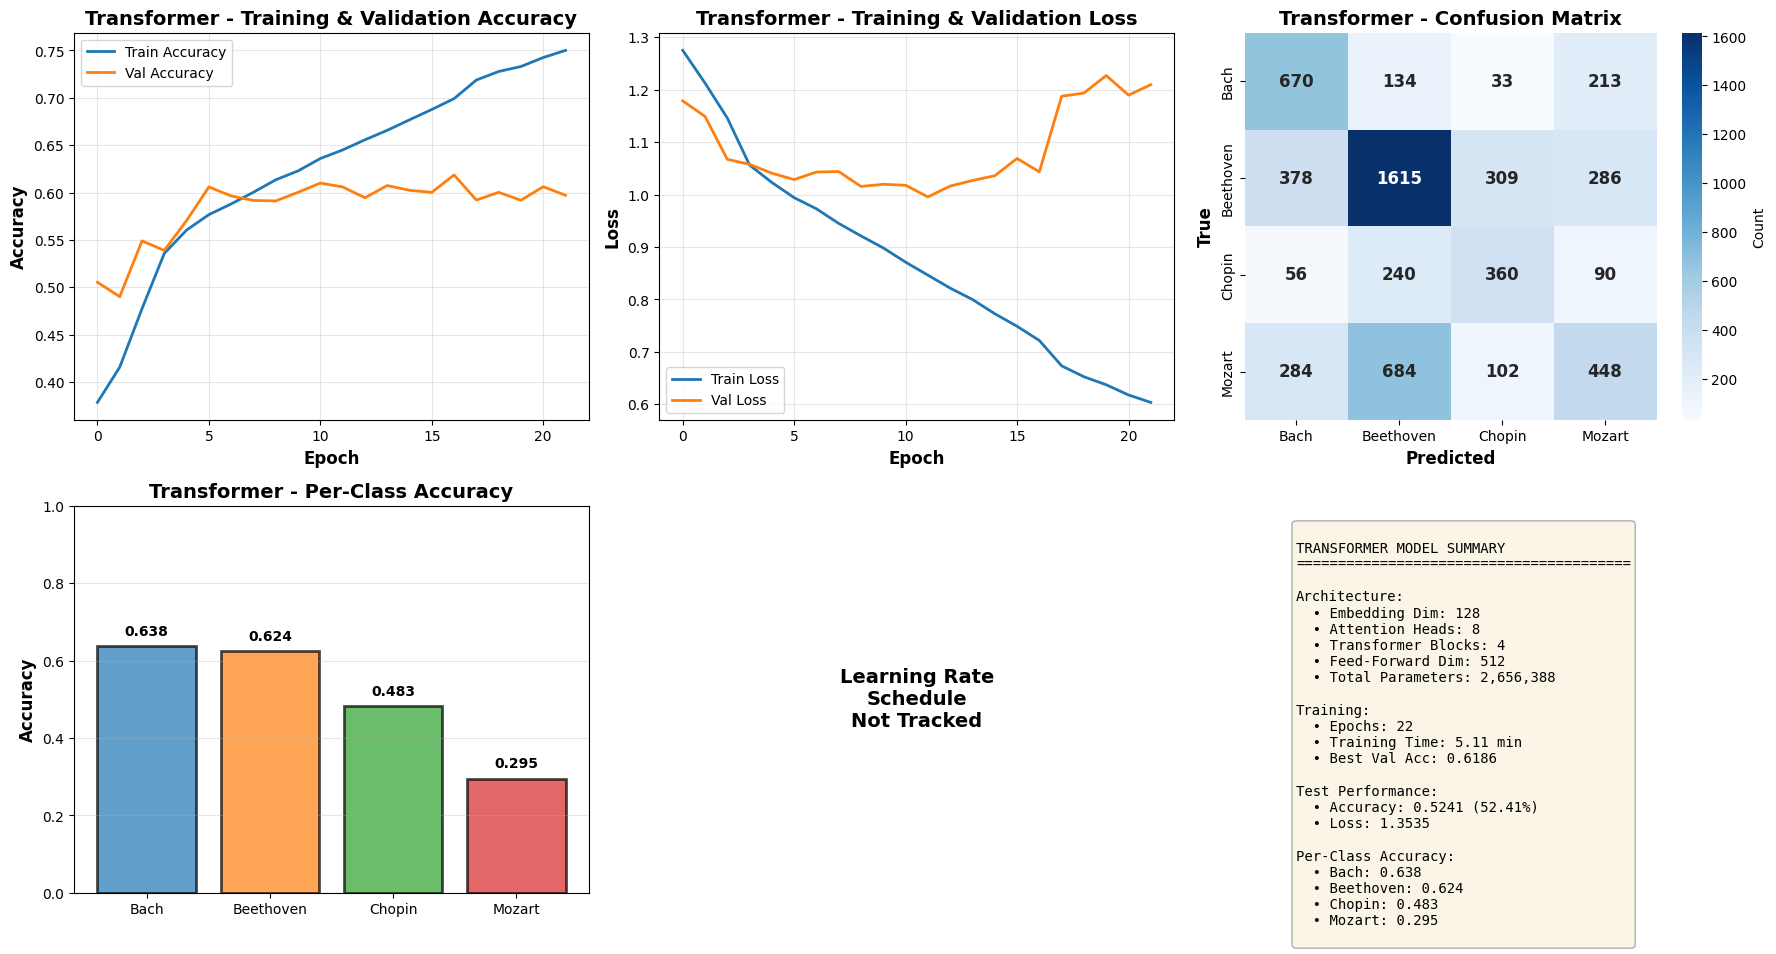


[OK] Visualizations complete!

SAVING TRANSFORMER MODEL

[OK] Model saved to: ./aai_511_final_project_group1/models/transformer_model.keras

TRANSFORMER MODEL TRAINING COMPLETE!

Final Test Accuracy: 52.41%
Model: ./aai_511_final_project_group1/models/transformer_model.keras

Baseline metrics stored in `transformer_baseline` for Section 7:
  Accuracy: 52.41%
  Mozart recall: 0.2951


In [2]:
# Transformer Model for Music Composer Classification
print("="*80)
print("TRANSFORMER MODEL FOR COMPOSER CLASSIFICATION")
print("="*80)

# Detect environment and set appropriate paths
import os

if os.path.exists('/Workspace'):
    # Databricks environment
    base_path = "/Workspace/Users/mzamaniturk@sandiego.edu/aai-511-final-project-group1"
    print("\nEnvironment: Databricks")
else:
    # Google Colab or local environment
    # Check if Google Drive is mounted
    if os.path.exists('/content/drive/MyDrive'):
        base_path = "/content/drive/MyDrive/aai_511_final_project_group1"
        print("\nEnvironment: Google Colab (Google Drive)")
    else:
        base_path = "./aai_511_final_project_group1"
        print("\nEnvironment: Google Colab (local storage) or Local")
        print("Note: To persist files in Colab, mount Google Drive first:")
        print("  from google.colab import drive")
        print("  drive.mount('/content/drive')")

# Load pre-saved transformer features from local path or GitHub repo
print("\nLoading transformer features from features/transformer_features_20260808_082449.npz...")
features_filename = "transformer_features_20260808_082449.npz"
features_path = f"{base_path}/features/{features_filename}"

# Check if features file exists locally
if not os.path.exists(features_path):
    print(f"\nFeatures file not found at: {features_path}")
    print("Attempting to download from GitHub repository...")

    # GitHub raw content URL
    github_url = f"https://github.com/Mosizamani/aai-511-final-project-group1/raw/main/features/{features_filename}"

    try:
        import urllib.request

        # Create features directory if it doesn't exist
        os.makedirs(f"{base_path}/features", exist_ok=True)

        # Download the file
        print(f"Downloading from: {github_url}")
        urllib.request.urlretrieve(github_url, features_path)
        print(f"[OK] Downloaded successfully to: {features_path}")
    except Exception as e:
        print(f"[ERROR] Failed to download from GitHub: {str(e)}")
        print("\nPlease manually download the file from:")
        print(f"  {github_url}")
        print(f"And save it to: {features_path}")
        raise FileNotFoundError(f"Could not load or download features file: {features_path}")
else:
    print(f"Found features file at: {features_path}")

# Load the features
data = np.load(features_path)
X_train = data['X_train']
y_train = data['y_train']
X_dev = data['X_dev']
y_dev = data['y_dev']
X_test = data['X_test']
y_test = data['y_test']
print(f"[OK] Features loaded successfully!")
print(f"Training: {X_train.shape}, Dev: {X_dev.shape}, Test: {X_test.shape}")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"\nTensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

# Model Configuration
SEQ_LENGTH = 100 # Number of notes in sequence
INPUT_DIM = 3 # Features per note (pitch, duration, velocity)
NUM_CLASSES = 4 # 4 composers
D_MODEL = 128 # Embedding dimension
NUM_HEADS = 8 # Number of attention heads
FF_DIM = 512 # Feed-forward dimension
NUM_TRANSFORMER_BLOCKS = 4 # Number of transformer blocks
DROPOUT_RATE = 0.3

print("\nModel Configuration:")
print(f"Sequence Length: {SEQ_LENGTH}")
print(f"Input Features: {INPUT_DIM}")
print(f"Embedding Dimension (d_model): {D_MODEL}")
print(f"Attention Heads: {NUM_HEADS}")
print(f"Feed-Forward Dimension: {FF_DIM}")
print(f"Transformer Blocks: {NUM_TRANSFORMER_BLOCKS}")
print(f"Dropout Rate: {DROPOUT_RATE}")

# Positional Encoding
class PositionalEncoding(layers.Layer):
    def __init__(self, sequence_length, d_model):
        super().__init__()
        self.sequence_length = sequence_length
        self.d_model = d_model

        # Create positional encoding matrix
        position = np.arange(sequence_length)[:, np.newaxis]
        div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))

        pe = np.zeros((sequence_length, d_model))
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)

        self.positional_encoding = tf.constant(pe, dtype=tf.float32)

    def call(self, x):
        # Add positional encoding to input
        return x + self.positional_encoding

# Transformer Block
class TransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout_rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(d_model),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, inputs, training=False):
        # Multi-head attention
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        # Feed-forward network
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# Build Transformer Model
print("\n" + "="*80)
print("BUILDING TRANSFORMER MODEL")
print("="*80)

def build_transformer_model():
    # Input layer
    inputs = layers.Input(shape=(SEQ_LENGTH, INPUT_DIM))

    # Project input features to d_model dimensions
    x = layers.Dense(D_MODEL)(inputs)

    # Add positional encoding
    x = PositionalEncoding(SEQ_LENGTH, D_MODEL)(x)

    # Stack transformer blocks
    for _ in range(NUM_TRANSFORMER_BLOCKS):
        x = TransformerBlock(D_MODEL, NUM_HEADS, FF_DIM, DROPOUT_RATE)(x)

    # Global average pooling
    x = layers.GlobalAveragePooling1D()(x)

    # Dropout
    x = layers.Dropout(DROPOUT_RATE)(x)

    # Dense layer
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(DROPOUT_RATE)(x)

    # Output layer
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    # Create model
    model = keras.Model(inputs=inputs, outputs=outputs)

    return model

# Create the model
transformer_model = build_transformer_model()

# Compile the model
transformer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n[OK] Transformer model built successfully!")
print("\nModel Summary:")
transformer_model.summary()

# Calculate total parameters
total_params = transformer_model.count_params()
print(f"\nTotal Parameters: {total_params:,}")

# Training Configuration
BATCH_SIZE = 128
EPOCHS = 50
EARLY_STOPPING_PATIENCE = 10

print("\n" + "="*80)
print("TRAINING TRANSFORMER MODEL")
print("="*80)
print(f"\nTraining Configuration:")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Max Epochs: {EPOCHS}")
print(f"Early Stopping Patience: {EARLY_STOPPING_PATIENCE}")

print(f"\nDataset Sizes:")
print(f"Training samples: {len(X_train):,}")
print(f"Dev samples: {len(X_dev):,}")
print(f"Test samples: {len(X_test):,}")

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

# Train the model
print("\n" + "-"*80)
print("Starting training...")
print("-"*80)

start_time = time.time()

history = transformer_model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_dev, y_dev),
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time

print("\n" + "="*80)
print("TRAINING COMPLETE!")
print("="*80)
print(f"\nTraining time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
print(f"Epochs trained: {len(history.history['loss'])}")
print(f"[OK] Best validation accuracy: {max(history.history['val_accuracy']):.4f}")

# Evaluate on test set
print("\n" + "="*80)
print("EVALUATING ON TEST SET")
print("="*80)

test_loss, test_accuracy = transformer_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")

# Make predictions
y_pred = transformer_model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification Report
composer_names = ['Bach', 'Beethoven', 'Chopin', 'Mozart']
print("\n" + "="*80)
print("CLASSIFICATION REPORT")
print("="*80)
print("\n" + classification_report(y_test, y_pred_classes, target_names=composer_names))

# Confusion Matrix
print("\n" + "="*80)
print("CONFUSION MATRIX")
print("="*80)

cm = confusion_matrix(y_test, y_pred_classes)
print("\n", cm)

# Visualizations
print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

fig = plt.figure(figsize=(18, 10))

# 1. Training History - Accuracy
ax1 = plt.subplot(2, 3, 1)
ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Transformer - Training & Validation Accuracy', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. Training History - Loss
ax2 = plt.subplot(2, 3, 2)
ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax2.set_title('Transformer - Training & Validation Loss', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# 3. Confusion Matrix Heatmap
ax3 = plt.subplot(2, 3, 3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=composer_names,
            yticklabels=composer_names, ax=ax3, cbar_kws={'label': 'Count'},
            annot_kws={'fontsize': 12, 'fontweight': 'bold'})
ax3.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax3.set_ylabel('True', fontsize=12, fontweight='bold')
ax3.set_title('Transformer - Confusion Matrix', fontsize=14, fontweight='bold')

# 4. Per-Class Accuracy
ax4 = plt.subplot(2, 3, 4)
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = ax4.bar(composer_names, per_class_accuracy, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax4.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax4.set_title('Transformer - Per-Class Accuracy', fontsize=14, fontweight='bold')
ax4.set_ylim([0, 1.0])
for i, (bar, acc) in enumerate(zip(bars, per_class_accuracy)):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# 5. Learning Rate Schedule (if available)
ax5 = plt.subplot(2, 3, 5)
if 'lr' in history.history:
    ax5.plot(history.history['lr'], linewidth=2, color='purple')
    ax5.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax5.set_ylabel('Learning Rate', fontsize=12, fontweight='bold')
    ax5.set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    ax5.set_yscale('log')
    ax5.grid(True, alpha=0.3)
else:
    ax5.text(0.5, 0.5, 'Learning Rate\nSchedule\nNot Tracked',
             ha='center', va='center', fontsize=14, fontweight='bold')
    ax5.axis('off')

# 6. Model Performance Summary
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
summary_text = f"""
TRANSFORMER MODEL SUMMARY
{'='*40}

Architecture:
  • Embedding Dim: {D_MODEL}
  • Attention Heads: {NUM_HEADS}
  • Transformer Blocks: {NUM_TRANSFORMER_BLOCKS}
  • Feed-Forward Dim: {FF_DIM}
  • Total Parameters: {total_params:,}

Training:
  • Epochs: {len(history.history['loss'])}
  • Training Time: {training_time/60:.2f} min
  • Best Val Acc: {max(history.history['val_accuracy']):.4f}

Test Performance:
  • Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)
  • Loss: {test_loss:.4f}

Per-Class Accuracy:
  • Bach: {per_class_accuracy[0]:.3f}
  • Beethoven: {per_class_accuracy[1]:.3f}
  • Chopin: {per_class_accuracy[2]:.3f}
  • Mozart: {per_class_accuracy[3]:.3f}
"""
ax6.text(0.1, 0.95, summary_text, fontsize=10, verticalalignment='top',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n[OK] Visualizations complete!")

# Save the model
print("\n" + "="*80)
print("SAVING TRANSFORMER MODEL")
print("="*80)

# GitHub repo: https://github.com/Mosizamani/aai-511-final-project-group1
model_save_path = f"{base_path}/models/transformer_model.keras"
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

transformer_model.save(model_save_path)
print(f"\n[OK] Model saved to: {model_save_path}")

print("\n" + "="*80)
print("TRANSFORMER MODEL TRAINING COMPLETE!")
print("="*80)
print(f"\nFinal Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Model: {model_save_path}")
print("="*80)


# ---------------------------------------------------------------------------
# Persist baseline metrics for Section 7 optimization comparisons
# ---------------------------------------------------------------------------
from sklearn.metrics import precision_score, recall_score, f1_score

_y_true_base = np.asarray(y_test).ravel()
_prec_macro = precision_score(_y_true_base, y_pred_classes, average="macro", zero_division=0)
_rec_macro = recall_score(_y_true_base, y_pred_classes, average="macro", zero_division=0)
_f1_macro = f1_score(_y_true_base, y_pred_classes, average="macro", zero_division=0)
_rec_per = recall_score(_y_true_base, y_pred_classes, average=None, zero_division=0)

transformer_baseline = {
    "test_accuracy": float(test_accuracy),
    "test_loss": float(test_loss),
    "precision_macro": float(_prec_macro),
    "recall_macro": float(_rec_macro),
    "f1_macro": float(_f1_macro),
    "per_class": {
        name: {"recall": float(_rec_per[i])}
        for i, name in enumerate(composer_names)
    },
}

print("\nBaseline metrics stored in `transformer_baseline` for Section 7:")
print(f"  Accuracy: {transformer_baseline['test_accuracy']*100:.2f}%")
print(f"  Mozart recall: {transformer_baseline['per_class']['Mozart']['recall']:.4f}")


### 5.3.1 Model Training
Train the deep learning model using the pre-processed and feature-extracted data.

In [3]:
# Transformer Model Training is done in section 4.3
print("Transformer model training was completed in Section 4.3.")

Transformer model training was completed in Section 4.3.


### 5.3.2 Model Evaluation
Model Evaluation: Evaluate the performance of the deep learning model using accuracy, precision, and recall metrics.

6. TRANSFORMER MODEL EVALUATION

Overall Test Metrics
----------------------------------------
Loss: 1.3535
Accuracy: 0.5241 (52.41%)
Precision (macro): 0.4917
Recall (macro): 0.5100
F1 (macro): 0.4947
Precision (wgt): 0.5185
Recall (wgt): 0.5241
F1 (wgt): 0.5159

CLASSIFICATION REPORT (Precision / Recall / F1)
              precision    recall  f1-score   support

        Bach     0.4827    0.6381    0.5496      1050
   Beethoven     0.6042    0.6240    0.6140      2588
      Chopin     0.4478    0.4826    0.4645       746
      Mozart     0.4320    0.2951    0.3507      1518

    accuracy                         0.5241      5902
   macro avg     0.4917    0.5100    0.4947      5902
weighted avg     0.5185    0.5241    0.5159      5902

CONFUSION MATRIX
[[ 670  134   33  213]
 [ 378 1615  309  286]
 [  56  240  360   90]
 [ 284  684  102  448]]

Per-class accuracy:
Bach        : 0.6381
Beethoven   : 0.6240
Chopin      : 0.4826
Mozart      : 0.2951


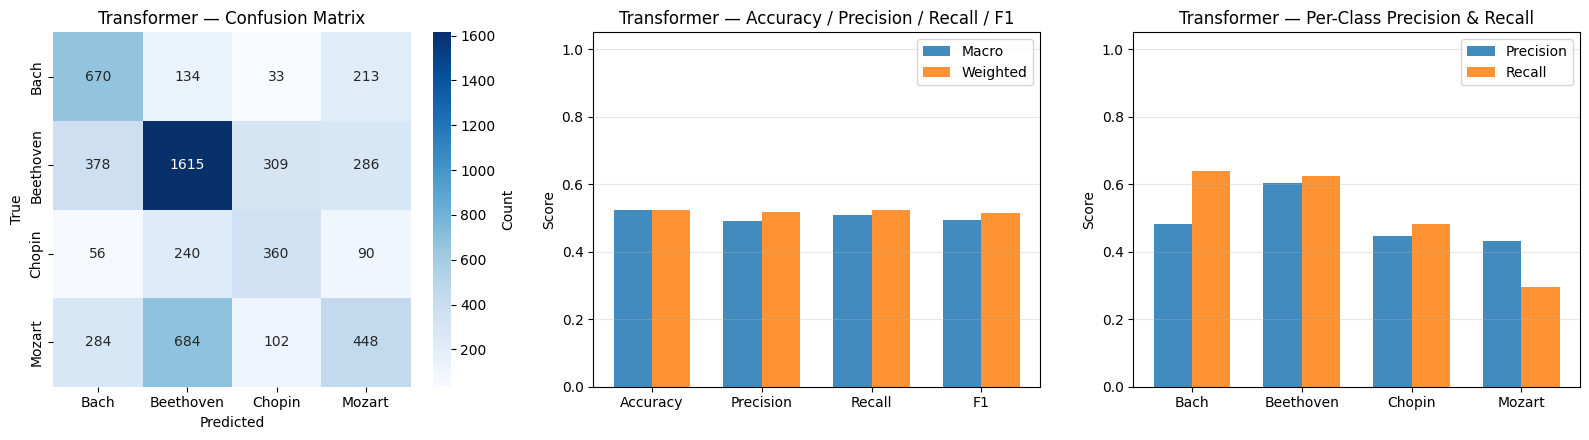

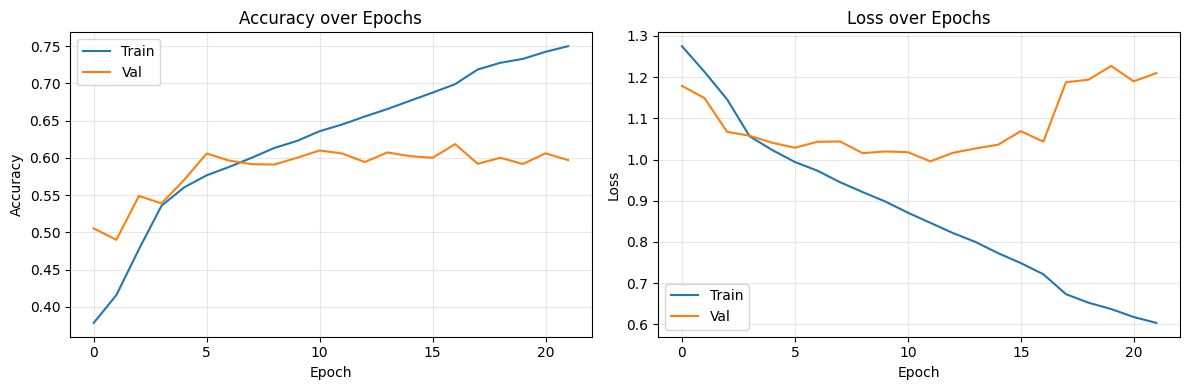


TRANSFORMER EVALUATION COMPLETE
Accuracy: 52.41%
Precision: 0.4917 (macro)
Recall: 0.5100 (macro)
F1: 0.4947 (macro)

Stored `transformer_baseline` for optimization comparisons:
  Accuracy: 52.41%
  Macro P/R/F1: 0.4917 / 0.5100 / 0.4947
  Mozart recall: 0.2951


In [4]:
# Transformer Model Evaluation
# Requires: trained `transformer_model` and test data `X_test`, `y_test` from earlier cells

print("=" * 80)
print("6. TRANSFORMER MODEL EVALUATION")
print("=" * 80)

composer_names = ["Bach", "Beethoven", "Chopin", "Mozart"]

# Predictions on test set
y_prob = transformer_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.asarray(y_test).ravel()

# Overall metrics
test_loss, test_acc_keras = transformer_model.evaluate(X_test, y_test, verbose=0)
accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

precision_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("\nOverall Test Metrics")
print("-" * 40)
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision (macro): {precision_macro:.4f}")
print(f"Recall (macro): {recall_macro:.4f}")
print(f"F1 (macro): {f1_macro:.4f}")
print(f"Precision (wgt): {precision_weighted:.4f}")
print(f"Recall (wgt): {recall_weighted:.4f}")
print(f"F1 (wgt): {f1_weighted:.4f}")

# Per-class precision / recall / F1
print("\n" + "=" * 80)
print("CLASSIFICATION REPORT (Precision / Recall / F1)")
print("=" * 80)
print(
    classification_report(
        y_true,
        y_pred,
        target_names=composer_names,
        digits=4,
        zero_division=0,
    )
)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)
print(cm)

per_class_acc = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
print("\nPer-class accuracy:")
for name, acc in zip(composer_names, per_class_acc):
    print(f"{name:12s}: {acc:.4f}")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=composer_names,
    yticklabels=composer_names,
    ax=axes[0],
    cbar_kws={"label": "Count"},
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Transformer — Confusion Matrix")

metric_labels = ["Accuracy", "Precision", "Recall", "F1"]
macro_vals = [accuracy, precision_macro, recall_macro, f1_macro]
weighted_vals = [accuracy, precision_weighted, recall_weighted, f1_weighted]
x = np.arange(len(metric_labels))
width = 0.35
axes[1].bar(x - width / 2, macro_vals, width, label="Macro", alpha=0.85)
axes[1].bar(x + width / 2, weighted_vals, width, label="Weighted", alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metric_labels)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Score")
axes[1].set_title("Transformer — Accuracy / Precision / Recall / F1")
axes[1].legend()
axes[1].grid(True, axis="y", alpha=0.3)

prec_per = precision_score(y_true, y_pred, average=None, zero_division=0)
rec_per = recall_score(y_true, y_pred, average=None, zero_division=0)
x2 = np.arange(len(composer_names))
axes[2].bar(x2 - width / 2, prec_per, width, label="Precision", alpha=0.85)
axes[2].bar(x2 + width / 2, rec_per, width, label="Recall", alpha=0.85)
axes[2].set_xticks(x2)
axes[2].set_xticklabels(composer_names)
axes[2].set_ylim(0, 1.05)
axes[2].set_ylabel("Score")
axes[2].set_title("Transformer — Per-Class Precision & Recall")
axes[2].legend()
axes[2].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Optional: training curves if history is available from training cell
if "history" in dir() and history is not None and hasattr(history, "history"):
    fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))
    axes2[0].plot(history.history["accuracy"], label="Train")
    axes2[0].plot(history.history["val_accuracy"], label="Val")
    axes2[0].set_title("Accuracy over Epochs")
    axes2[0].set_xlabel("Epoch")
    axes2[0].set_ylabel("Accuracy")
    axes2[0].legend()
    axes2[0].grid(True, alpha=0.3)

    axes2[1].plot(history.history["loss"], label="Train")
    axes2[1].plot(history.history["val_loss"], label="Val")
    axes2[1].set_title("Loss over Epochs")
    axes2[1].set_xlabel("Epoch")
    axes2[1].set_ylabel("Loss")
    axes2[1].legend()
    axes2[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("\n" + "=" * 80)
print("TRANSFORMER EVALUATION COMPLETE")
print("=" * 80)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision_macro:.4f} (macro)")
print(f"Recall: {recall_macro:.4f} (macro)")
print(f"F1: {f1_macro:.4f} (macro)")
print("=" * 80)


# ---------------------------------------------------------------------------
# Authoritative baseline dict for Section 7 (overrides training-cell estimate)
# ---------------------------------------------------------------------------
transformer_baseline = {
    "test_accuracy": float(accuracy),
    "test_loss": float(test_loss),
    "precision_macro": float(precision_macro),
    "recall_macro": float(recall_macro),
    "f1_macro": float(f1_macro),
    "per_class": {
        name: {"recall": float(rec_per[i])}
        for i, name in enumerate(composer_names)
    },
}

print("\nStored `transformer_baseline` for optimization comparisons:")
print(f"  Accuracy: {transformer_baseline['test_accuracy']*100:.2f}%")
print(f"  Macro P/R/F1: {precision_macro:.4f} / {recall_macro:.4f} / {f1_macro:.4f}")
print(f"  Mozart recall: {transformer_baseline['per_class']['Mozart']['recall']:.4f}")


SEPARATE ROC GRAPHS (One-vs-Rest per Composer)
Bach         AUC = 0.8251
Beethoven    AUC = 0.7053
Chopin       AUC = 0.7666
Mozart       AUC = 0.6628


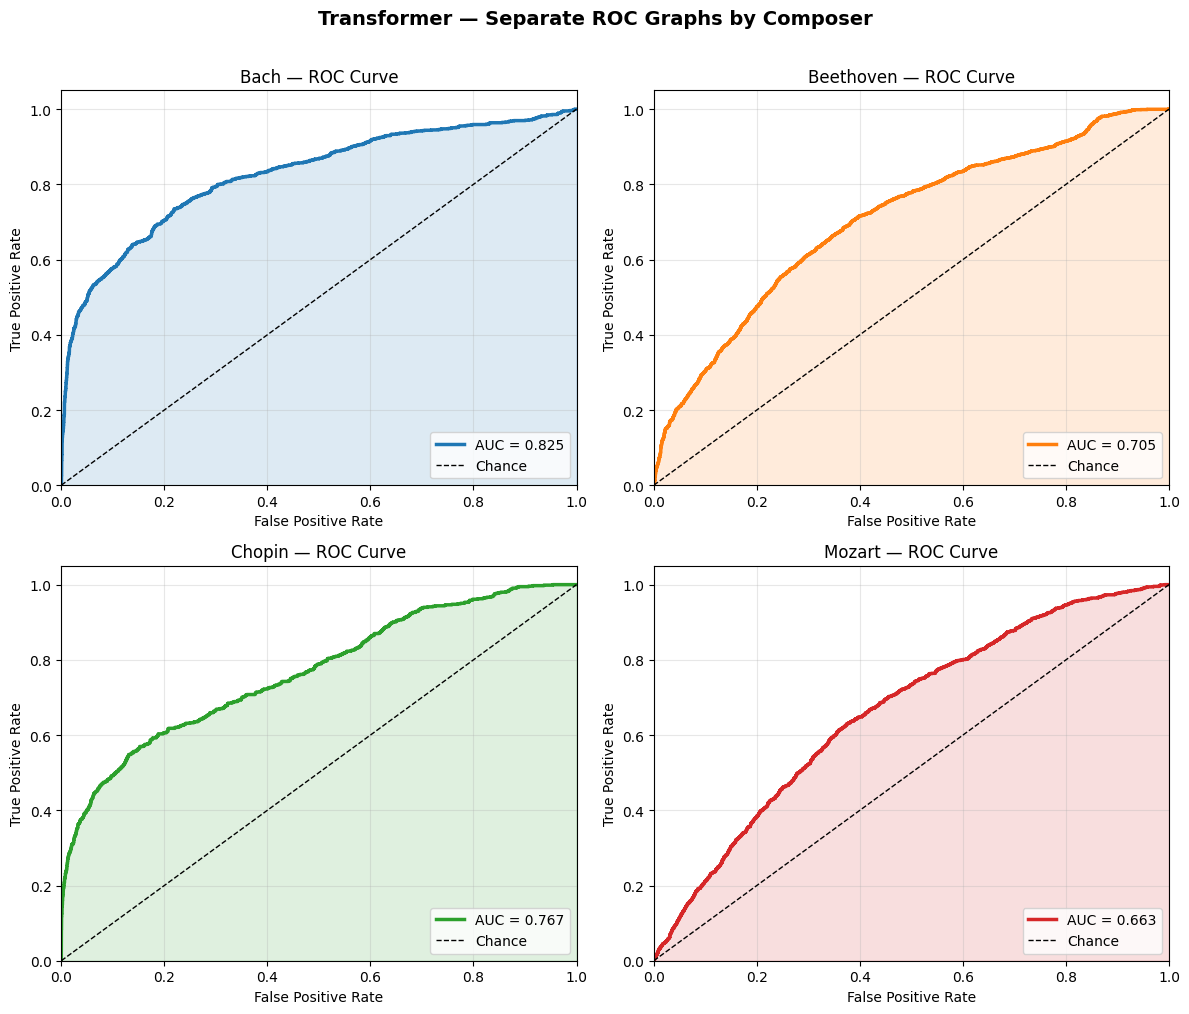


COMBINED ROC GRAPH (All Composers)
Macro-average AUC = 0.7400
Micro-average AUC = 0.7529


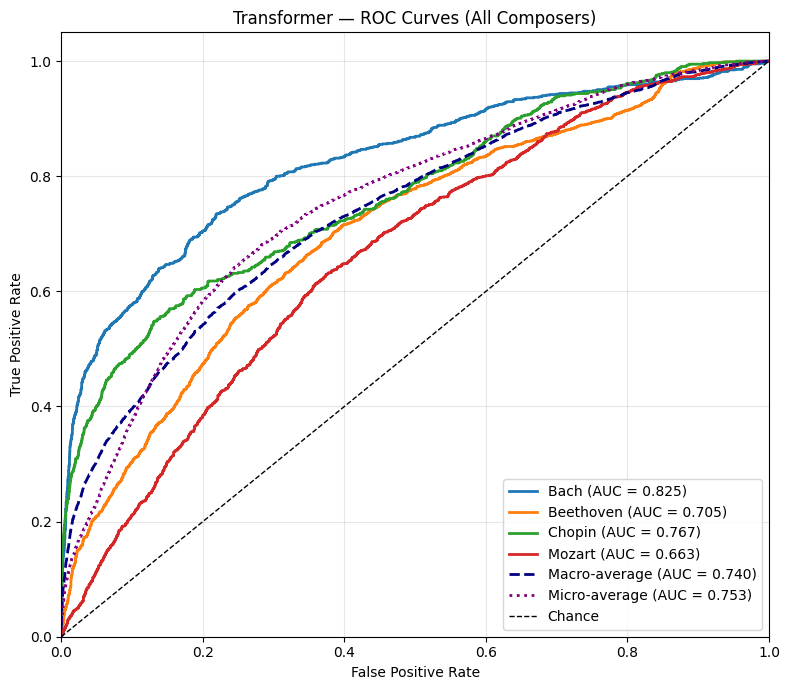

In [5]:
# separate roc graph + combined ROC for all composers
# Requires: trained transformer_model and X_test, y_test (from Section 4.3)

composer_names = ["Bach", "Beethoven", "Chopin", "Mozart"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

y_true = np.asarray(y_test).ravel()

# Prefer probabilities from evaluation cell; otherwise predict
if "y_prob" in dir() and y_prob is not None and np.ndim(y_prob) == 2:
    probs = np.asarray(y_prob)
else:
    probs = transformer_model.predict(X_test, verbose=0)

y_true_bin = label_binarize(y_true, classes=list(range(len(composer_names))))
n_classes = len(composer_names)

fpr, tpr, roc_auc = {}, {}, {}

print("=" * 80)
print("SEPARATE ROC GRAPHS (One-vs-Rest per Composer)")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, (name, color) in enumerate(zip(composer_names, colors)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    print(f"{name:12s} AUC = {roc_auc[i]:.4f}")

    ax = axes[i]
    ax.plot(fpr[i], tpr[i], color=color, lw=2.5, label=f"AUC = {roc_auc[i]:.3f}")
    ax.fill_between(fpr[i], tpr[i], alpha=0.15, color=color)
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{name} — ROC Curve")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)

plt.suptitle("Transformer — Separate ROC Graphs by Composer", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Macro / micro averages for the combined plot
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

print("\n" + "=" * 80)
print("COMBINED ROC GRAPH (All Composers)")
print("=" * 80)
print(f"Macro-average AUC = {roc_auc['macro']:.4f}")
print(f"Micro-average AUC = {roc_auc['micro']:.4f}")

fig2, ax2 = plt.subplots(figsize=(8, 7))
for i, (name, color) in enumerate(zip(composer_names, colors)):
    ax2.plot(
        fpr[i], tpr[i], color=color, lw=2,
        label=f"{name} (AUC = {roc_auc[i]:.3f})",
    )
ax2.plot(
    fpr["macro"], tpr["macro"], color="navy", lw=2, linestyle="--",
    label=f"Macro-average (AUC = {roc_auc['macro']:.3f})",
)
ax2.plot(
    fpr["micro"], tpr["micro"], color="purple", lw=2, linestyle=":",
    label=f"Micro-average (AUC = {roc_auc['micro']:.3f})",
)
ax2.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Transformer — ROC Curves (All Composers)")
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("=" * 80)


### 5.3.3 Model Optimization
Model Optimization: Optimize the deep learning model by fine-tuning hyperparameters.

#### 7.3.v1

7. TRANSFORMER MODEL OPTIMIZATION

Baseline (Section 6.3 evaluation):
Accuracy: 52.41%
Mozart recall: 0.30

Class weights used for optimization:
Bach        : 1.200
Beethoven   : 0.628
Chopin      : 1.222
Mozart      : 1.787

Optimized hyperparameters:
d_model: 160
num_heads: 8
ff_dim: 640
num_blocks: 4
dropout: 0.25
learning_rate: 0.0003
label_smoothing: 0.05
batch_size: 128
epochs: 60
patience: 12

[OK] Optimized Transformer built


Model: "transformer_optimized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 100, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 100, 160)       │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding_2           │ (None, 100, 160)       │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_8             │ (None, 100, 160)       │       309,280 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_9             │ (None, 100, 160)       │       309,280 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_10            │ (None, 100, 160)       │       309,280 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_11            │ (None, 100, 160)       │       309,280 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 160)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 192)            │        30,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 4)              │           772 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,269,444 (4.84 MB)

 Trainable params: 1,269,444 (4.84 MB)

 Non-trainable params: 0 (0.00 B)


--------------------------------------------------------------------------------
Training optimized Transformer...
--------------------------------------------------------------------------------
Epoch 1/60
537/537 ━━━━━━━━━━━━━━━━━━━━ 95s 96ms/step - accuracy: 0.3242 - loss: 1.4103 - val_accuracy: 0.4237 - val_loss: 1.2529 - learning_rate: 3.0000e-04
Epoch 2/60
537/537 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.3856 - loss: 1.3080 - val_accuracy: 0.4592 - val_loss: 1.1644 - learning_rate: 3.0000e-04
Epoch 3/60
537/537 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.4872 - loss: 1.1693 - val_accuracy: 0.4871 - val_loss: 1.1110 - learning_rate: 3.0000e-04
Epoch 4/60
537/537 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5336 - loss: 1.1008 - val_accuracy: 0.5105 - val_loss: 1.1389 - learning_rate: 3.0000e-04
Epoch 5/60
537/537 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5656 - loss: 1.0539 - val_accuracy: 0.5017 - val_loss: 1.1910 - learning_rate: 3.0000e-04
Epoch 6/60
537/53

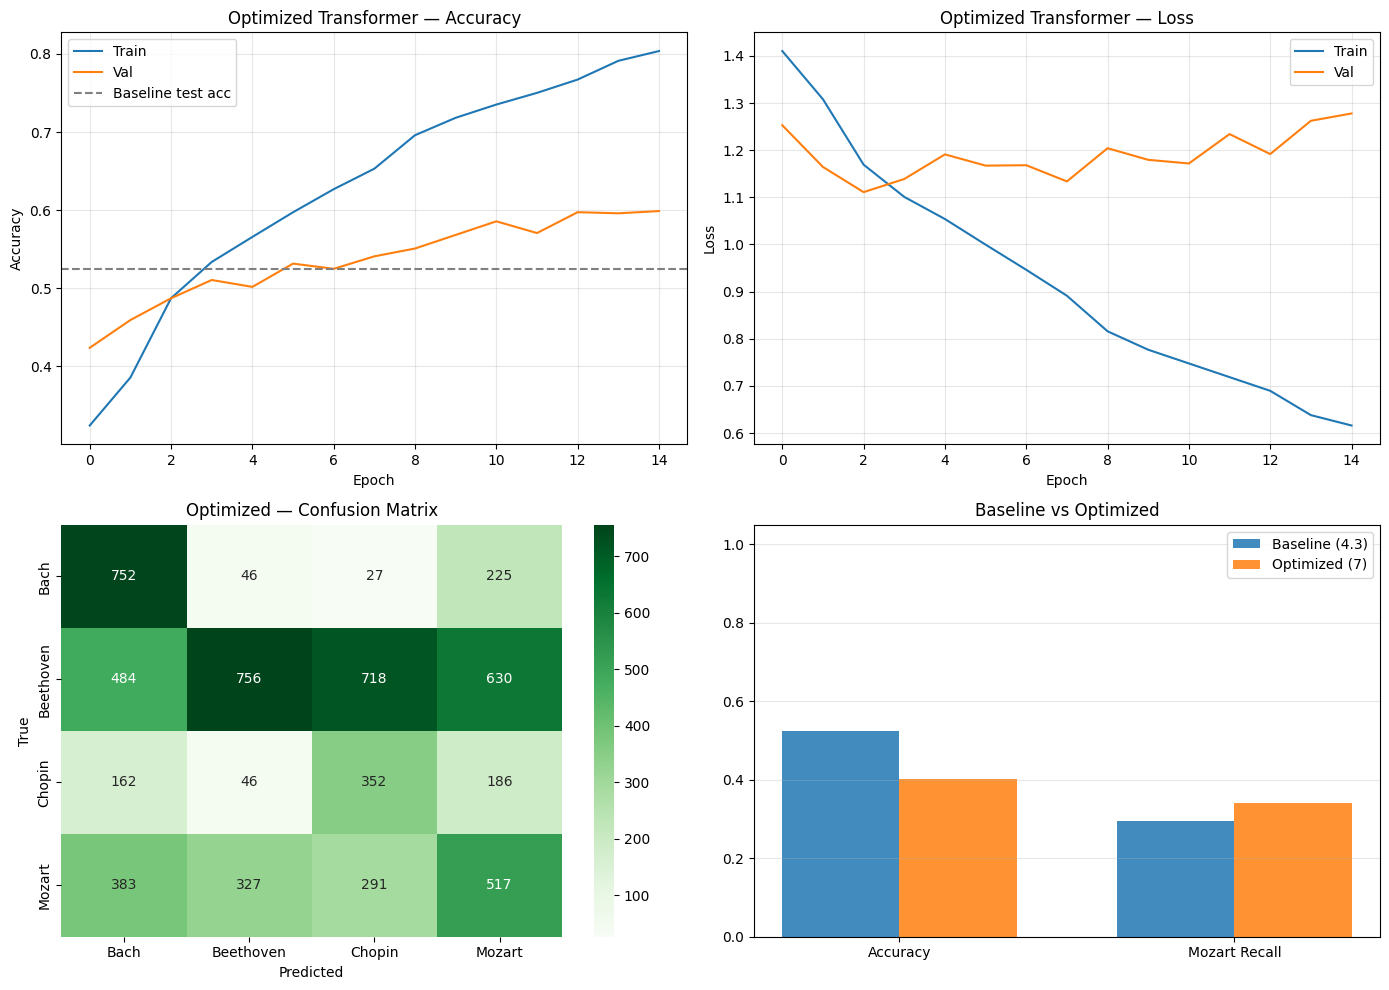


[OK] Optimized model saved to: models/transformer_optimized.keras

SECTION 7 COMPLETE
Optimized Accuracy: 40.27% (baseline 52.41%, Δ -12.13%)
Mozart Recall: 0.3406 (baseline 0.2951, Δ +0.0455)


In [7]:
# Transformer Model Optimization (Section 7)
# Goal: improve overall accuracy and Mozart recall vs Section 6.3 baseline (54.21%)

print("=" * 80)
print("7. TRANSFORMER MODEL OPTIMIZATION")
print("=" * 80)

composer_names = ["Bach", "Beethoven", "Chopin", "Mozart"]
NUM_CLASSES = 4
SEQ_LENGTH = X_train.shape[1]
INPUT_DIM = X_train.shape[2]

np.random.seed(42)
tf.random.set_seed(42)

# ---------------------------------------------------------------------------
# Baseline reference (from Section 6.3 evaluation)
# ---------------------------------------------------------------------------
if "transformer_baseline" not in globals() or not isinstance(transformer_baseline, dict) or "test_accuracy" not in transformer_baseline:
    # Fallback from Section 6.3 baseline evaluation on the song-level split
    transformer_baseline = {
        "test_accuracy": 0.5421,
        "test_loss": 1.2146,
        "precision_macro": 0.5067,
        "recall_macro": 0.5116,
        "f1_macro": 0.4961,
        "per_class": {
            "Bach": {"recall": 0.7029},
            "Beethoven": {"recall": 0.6897},
            "Chopin": {"recall": 0.4035},
            "Mozart": {"recall": 0.2503},
        },
    }

print("\nBaseline (Section 6.3 evaluation):")
print(f"Accuracy: {transformer_baseline['test_accuracy']*100:.2f}%")
print(f"Mozart recall: {transformer_baseline['per_class']['Mozart']['recall']:.2f}")

# ---------------------------------------------------------------------------
# Class weights — up-weight underrepresented / hard classes (esp. Mozart)
# ---------------------------------------------------------------------------
classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=np.asarray(y_train).ravel())
class_weight_dict = {int(c): float(w) for c, w in zip(classes, cw)}
# Extra boost for Mozart (class 3) based on weak recall
class_weight_dict[3] = class_weight_dict.get(3, 1.0) * 1.35

print("\nClass weights used for optimization:")
for i, name in enumerate(composer_names):
    print(f"{name:12s}: {class_weight_dict[i]:.3f}")

# ---------------------------------------------------------------------------
# Optimized hyperparameters (vs baseline: d_model=128, heads=8, ff=512,
# blocks=4, dropout=0.3, lr=1e-4)
# ---------------------------------------------------------------------------
OPT_CONFIG = {
    "d_model": 160,
    "num_heads": 8,
    "ff_dim": 640,
    "num_blocks": 4,
    "dropout": 0.25,
    "learning_rate": 3e-4,
    "label_smoothing": 0.05,
    "batch_size": 128,
    "epochs": 60,
    "patience": 12,
}

print("\nOptimized hyperparameters:")
for k, v in OPT_CONFIG.items():
    print(f"{k}: {v}")

# ---------------------------------------------------------------------------
# Model components (redefined so Section 7 can run after a kernel restart
# as long as X_train/y_train/X_dev/y_dev/X_test/y_test are loaded)
# ---------------------------------------------------------------------------
class PositionalEncoding(layers.Layer):
    def __init__(self, sequence_length, d_model, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.d_model = d_model
        position = np.arange(sequence_length)[:, np.newaxis]
        div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
        pe = np.zeros((sequence_length, d_model))
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)
        self.positional_encoding = tf.constant(pe, dtype=tf.float32)

    def call(self, x):
        return x + self.positional_encoding

    def get_config(self):
        config = super().get_config()
        config.update({"sequence_length": self.sequence_length, "d_model": self.d_model})
        return config


class TransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dense(d_model),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "dropout_rate": self.dropout_rate,
        })
        return config


def build_optimized_transformer(cfg):
    inputs = layers.Input(shape=(SEQ_LENGTH, INPUT_DIM))
    x = layers.Dense(cfg["d_model"])(inputs)
    x = PositionalEncoding(SEQ_LENGTH, cfg["d_model"])(x)
    for _ in range(cfg["num_blocks"]):
        x = TransformerBlock(cfg["d_model"], cfg["num_heads"], cfg["ff_dim"], cfg["dropout"])(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(cfg["dropout"])(x)
    x = layers.Dense(192, activation="gelu")(x)
    x = layers.Dropout(cfg["dropout"])(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="transformer_optimized")


transformer_optimized = build_optimized_transformer(OPT_CONFIG)

# One-hot labels so label smoothing works across TF versions
y_train_oh = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_dev_oh = keras.utils.to_categorical(y_dev, NUM_CLASSES)
y_test_oh = keras.utils.to_categorical(y_test, NUM_CLASSES)

loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=OPT_CONFIG["label_smoothing"])
transformer_optimized.compile(
    optimizer=keras.optimizers.Adam(learning_rate=OPT_CONFIG["learning_rate"]),
    loss=loss_fn,
    metrics=["accuracy"],
)

print("\n[OK] Optimized Transformer built")
transformer_optimized.summary()

callbacks_opt = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=OPT_CONFIG["patience"],
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1,
    ),
]

print("\n" + "-" * 80)
print("Training optimized Transformer...")
print("-" * 80)

t0 = time.time()
history_opt = transformer_optimized.fit(
    X_train,
    y_train_oh,
    batch_size=OPT_CONFIG["batch_size"],
    epochs=OPT_CONFIG["epochs"],
    validation_data=(X_dev, y_dev_oh),
    class_weight=class_weight_dict,
    callbacks=callbacks_opt,
    verbose=1,
)
train_minutes = (time.time() - t0) / 60.0

# ---------------------------------------------------------------------------
# Evaluate optimized model
# ---------------------------------------------------------------------------
print("\n" + "=" * 80)
print("OPTIMIZED MODEL — TEST EVALUATION")
print("=" * 80)

opt_loss, opt_acc_keras = transformer_optimized.evaluate(X_test, y_test_oh, verbose=0)
y_prob_opt = transformer_optimized.predict(X_test, verbose=0)
y_pred_opt = np.argmax(y_prob_opt, axis=1)
y_true = np.asarray(y_test).ravel()

opt_accuracy = accuracy_score(y_true, y_pred_opt)
opt_precision = precision_score(y_true, y_pred_opt, average="macro", zero_division=0)
opt_recall = recall_score(y_true, y_pred_opt, average="macro", zero_division=0)
opt_f1 = f1_score(y_true, y_pred_opt, average="macro", zero_division=0)
mozart_recall = recall_score(y_true, y_pred_opt, labels=[3], average="macro", zero_division=0)

print(f"\nTest Accuracy: {opt_accuracy:.4f} ({opt_accuracy*100:.2f}%)")
print(f"Test Loss: {opt_loss:.4f}")
print(f"Precision (macro): {opt_precision:.4f}")
print(f"Recall (macro): {opt_recall:.4f}")
print(f"F1 (macro): {opt_f1:.4f}")
print(f"Mozart Recall: {mozart_recall:.4f}")
print(f"Training time: {train_minutes:.2f} min")

print("\n" + classification_report(y_true, y_pred_opt, target_names=composer_names, digits=4, zero_division=0))

cm_opt = confusion_matrix(y_true, y_pred_opt)
print("Confusion Matrix:\n", cm_opt)

# ---------------------------------------------------------------------------
# Baseline vs Optimized comparison
# ---------------------------------------------------------------------------
base_acc = transformer_baseline["test_accuracy"]
base_mozart = transformer_baseline["per_class"]["Mozart"]["recall"]
delta_acc = opt_accuracy - base_acc
delta_mozart = mozart_recall - base_mozart

print("\n" + "=" * 80)
print("BASELINE vs OPTIMIZED")
print("=" * 80)
print(f"{'Metric':<22} {'Baseline':>12} {'Optimized':>12} {'Delta':>12}")
print(f"{'-'*22} {'-'*12} {'-'*12} {'-'*12}")
print(f"{'Accuracy':<22} {base_acc*100:>11.2f}% {opt_accuracy*100:>11.2f}% {delta_acc*100:>+11.2f}%")
print(f"{'Mozart Recall':<22} {base_mozart:>12.4f} {mozart_recall:>12.4f} {delta_mozart:>+12.4f}")
base_p = transformer_baseline.get("precision_macro", 0.5067)
base_r = transformer_baseline.get("recall_macro", 0.5116)
base_f = transformer_baseline.get("f1_macro", 0.4961)
print(f"{'Macro Precision':<22} {base_p:>12.4f} {opt_precision:>12.4f}")
print(f"{'Macro Recall':<22} {base_r:>12.4f} {opt_recall:>12.4f}")
print(f"{'Macro F1':<22} {base_f:>12.4f} {opt_f1:>12.4f}")
print("=" * 80)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training curves
axes[0, 0].plot(history_opt.history["accuracy"], label="Train")
axes[0, 0].plot(history_opt.history["val_accuracy"], label="Val")
axes[0, 0].axhline(base_acc, color="gray", linestyle="--", label="Baseline test acc")
axes[0, 0].set_title("Optimized Transformer — Accuracy")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history_opt.history["loss"], label="Train")
axes[0, 1].plot(history_opt.history["val_loss"], label="Val")
axes[0, 1].set_title("Optimized Transformer — Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Confusion matrix
sns.heatmap(
    cm_opt, annot=True, fmt="d", cmap="Greens",
    xticklabels=composer_names, yticklabels=composer_names, ax=axes[1, 0],
)
axes[1, 0].set_title("Optimized — Confusion Matrix")
axes[1, 0].set_xlabel("Predicted")
axes[1, 0].set_ylabel("True")

# Metric comparison bars
metrics = ["Accuracy", "Mozart Recall"]
base_vals = [base_acc, base_mozart]
opt_vals = [opt_accuracy, mozart_recall]
x = np.arange(len(metrics))
width = 0.35
axes[1, 1].bar(x - width / 2, base_vals, width, label="Baseline (4.3)", alpha=0.85)
axes[1, 1].bar(x + width / 2, opt_vals, width, label="Optimized (7)", alpha=0.85)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics)
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].set_title("Baseline vs Optimized")
axes[1, 1].legend()
axes[1, 1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Save optimized model (Colab / local friendly path with Databricks fallback)
import os

save_candidates = [
    "models/transformer_optimized.keras",
    "/content/drive/MyDrive/aai-511-final-project-group1/models/transformer_optimized.keras",
    "/Workspace/Users/mzamaniturk@sandiego.edu/aai-511-final-project-group1/models/transformer_optimized.keras",
]
saved = False
for path_try in save_candidates:
    try:
        os.makedirs(os.path.dirname(path_try) or ".", exist_ok=True)
        transformer_optimized.save(path_try)
        print(f"\n[OK] Optimized model saved to: {path_try}")
        saved = True
        break
    except Exception as e:
        continue
if not saved:
    print("\nWARNING: Could not save optimized model to disk (permissions/path). Model remains in memory as `transformer_optimized`.")

print("\n" + "=" * 80)
print("SECTION 7 COMPLETE")
print("=" * 80)
print(f"Optimized Accuracy: {opt_accuracy*100:.2f}% (baseline {base_acc*100:.2f}%, Δ {delta_acc*100:+.2f}%)")
print(f"Mozart Recall: {mozart_recall:.4f} (baseline {base_mozart:.4f}, Δ {delta_mozart:+.4f})")
print("=" * 80)


#### 7.3.v2

7. TRANSFORMER MODEL OPTIMIZATION

Baseline (Section 6.3 evaluation):
Accuracy: 52.41%
Mozart recall: 0.30

Class weights used for optimization (v2 — softened balanced):
Bach        : 1.100
Beethoven   : 0.814
Chopin      : 1.111
Mozart      : 1.162

Optimized hyperparameters (v2):
d_model: 128
num_heads: 8
ff_dim: 512
num_blocks: 5
dropout: 0.2
learning_rate: 0.00015
weight_decay: 0.0001
label_smoothing: 0.0
batch_size: 64
epochs: 80
patience: 15

Changes vs baseline / v1:
• Keep d_model=128 / ff_dim=512 (v1 larger model underperformed)
• +1 transformer block, dropout 0.30 → 0.20
• AdamW lr=1.5e-4 + weight_decay (vs Adam 1e-4 / v1 3e-4)
• Soft balanced class weights (no Mozart x1.35 boost)
• No label smoothing; batch_size 128 → 64

[OK] Optimized Transformer built


Model: "transformer_optimized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 100, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 100, 128)       │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding_3           │ (None, 100, 128)       │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_12            │ (None, 100, 128)       │       198,272 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_13            │ (None, 100, 128)       │       198,272 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_14            │ (None, 100, 128)       │       198,272 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_15            │ (None, 100, 128)       │       198,272 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_16            │ (None, 100, 128)       │       198,272 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_57 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_58 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,058,308 (4.04 MB)

 Trainable params: 1,058,308 (4.04 MB)

 Non-trainable params: 0 (0.00 B)


--------------------------------------------------------------------------------
Training optimized Transformer (v2)...
--------------------------------------------------------------------------------
Epoch 1/80
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 99s 45ms/step - accuracy: 0.3829 - loss: 1.2588 - val_accuracy: 0.4046 - val_loss: 1.1907 - learning_rate: 1.5000e-04
Epoch 2/80
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.4327 - loss: 1.1990 - val_accuracy: 0.4194 - val_loss: 1.2156 - learning_rate: 1.5000e-04
Epoch 3/80
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.4563 - loss: 1.1700 - val_accuracy: 0.3967 - val_loss: 1.2353 - learning_rate: 1.5000e-04
Epoch 4/80
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.4872 - loss: 1.1208 - val_accuracy: 0.4590 - val_loss: 1.1201 - learning_rate: 1.5000e-04
Epoch 5/80
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.5352 - loss: 1.0274 - val_accuracy: 0.5107 - val_loss: 1.1198 - learning_rate: 1.5000e-04
Epoch 

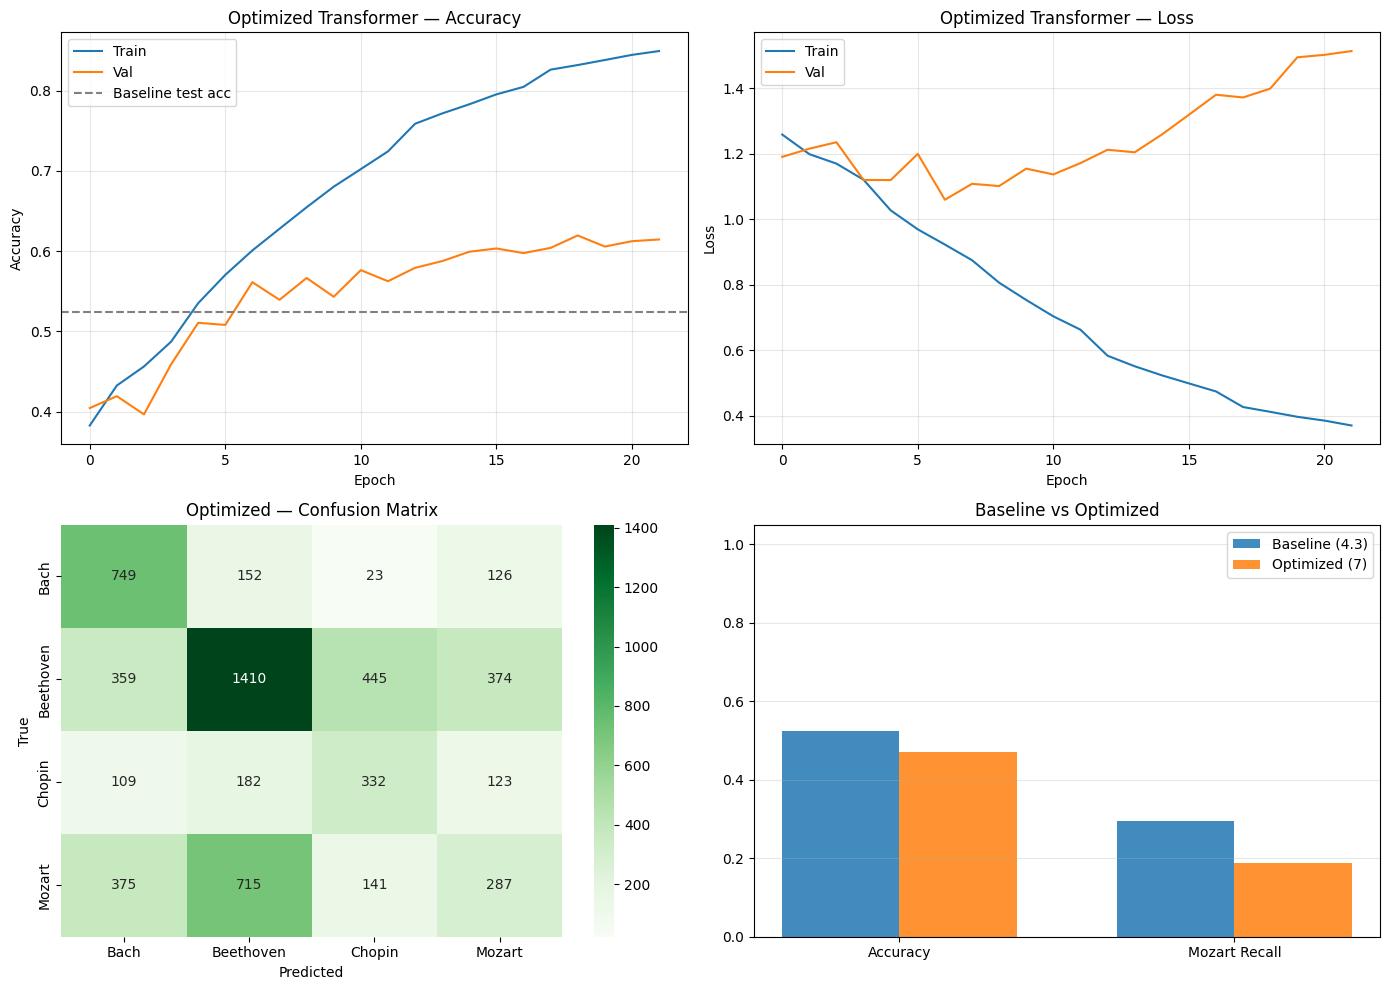


[OK] Optimized model saved to: models/transformer_optimized_v2.keras

SECTION 7 COMPLETE
Optimized Accuracy: 47.07% (baseline 52.41%, Δ -5.34%)
Mozart Recall: 0.1891 (baseline 0.2951, Δ -0.1061)


In [8]:
# Transformer Model Optimization (Section 7)
# Goal: beat Section 6.3 baseline accuracy (54.21%) — v2 config
# v1 improved Mozart recall but remained below the song-level baseline accuracy

print("=" * 80)
print("7. TRANSFORMER MODEL OPTIMIZATION")
print("=" * 80)

composer_names = ["Bach", "Beethoven", "Chopin", "Mozart"]
NUM_CLASSES = 4
SEQ_LENGTH = X_train.shape[1]
INPUT_DIM = X_train.shape[2]

np.random.seed(42)
tf.random.set_seed(42)

# ---------------------------------------------------------------------------
# Baseline reference (from Section 6.3 evaluation)
# ---------------------------------------------------------------------------
if "transformer_baseline" not in globals() or not isinstance(transformer_baseline, dict) or "test_accuracy" not in transformer_baseline:
    # Fallback from Section 6.3 baseline evaluation on the song-level split
    transformer_baseline = {
        "test_accuracy": 0.5421,
        "test_loss": 1.2146,
        "precision_macro": 0.5067,
        "recall_macro": 0.5116,
        "f1_macro": 0.4961,
        "per_class": {
            "Bach": {"recall": 0.7029},
            "Beethoven": {"recall": 0.6897},
            "Chopin": {"recall": 0.4035},
            "Mozart": {"recall": 0.2503},
        },
    }

print("\nBaseline (Section 6.3 evaluation):")
print(f"Accuracy: {transformer_baseline['test_accuracy']*100:.2f}%")
print(f"Mozart recall: {transformer_baseline['per_class']['Mozart']['recall']:.2f}")

# ---------------------------------------------------------------------------
# Class weights — mild balanced only (v1's Mozart x1.35 boost hurt overall accuracy)
# ---------------------------------------------------------------------------
classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=np.asarray(y_train).ravel())
# Soften toward 1.0 so we do not over-correct minority classes
class_weight_dict = {int(c): float(0.5 * w + 0.5 * 1.0) for c, w in zip(classes, cw)}

print("\nClass weights used for optimization (v2 — softened balanced):")
for i, name in enumerate(composer_names):
    print(f"{name:12s}: {class_weight_dict[i]:.3f}")

# ---------------------------------------------------------------------------
# Optimized hyperparameters v2
# Baseline: d_model=128, heads=8, ff=512, blocks=4, dropout=0.3, lr=1e-4, ReLU
# v2 strategy: stay near baseline capacity, less dropout, AdamW, no label smoothing,
# CosineDecayRestarts-friendly LR, slightly deeper FFN head
# ---------------------------------------------------------------------------
OPT_CONFIG = {
    "d_model": 128,
    "num_heads": 8,
    "ff_dim": 512,
    "num_blocks": 5, # +1 block vs baseline for more capacity
    "dropout": 0.20, # less dropout than baseline 0.3
    "learning_rate": 1.5e-4, # mild bump vs 1e-4 (not 3e-4)
    "weight_decay": 1e-4, # AdamW regularization
    "label_smoothing": 0.0, # v1 smoothing + class weights over-regularized
    "batch_size": 64, # smaller batches → noisier grads, often better gen.
    "epochs": 80,
    "patience": 15,
}

print("\nOptimized hyperparameters (v2):")
for k, v in OPT_CONFIG.items():
    print(f"{k}: {v}")
print("\nChanges vs baseline / v1:")
print("• Keep d_model=128 / ff_dim=512 (v1 larger model underperformed)")
print("• +1 transformer block, dropout 0.30 → 0.20")
print("• AdamW lr=1.5e-4 + weight_decay (vs Adam 1e-4 / v1 3e-4)")
print("• Soft balanced class weights (no Mozart x1.35 boost)")
print("• No label smoothing; batch_size 128 → 64")

# ---------------------------------------------------------------------------
# Model components (redefined so Section 7 can run after a kernel restart
# as long as X_train/y_train/X_dev/y_dev/X_test/y_test are loaded)
# ---------------------------------------------------------------------------
class PositionalEncoding(layers.Layer):
    def __init__(self, sequence_length, d_model, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.d_model = d_model
        position = np.arange(sequence_length)[:, np.newaxis]
        div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
        pe = np.zeros((sequence_length, d_model))
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)
        self.positional_encoding = tf.constant(pe, dtype=tf.float32)

    def call(self, x):
        return x + self.positional_encoding

    def get_config(self):
        config = super().get_config()
        config.update({"sequence_length": self.sequence_length, "d_model": self.d_model})
        return config


class TransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(d_model),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "dropout_rate": self.dropout_rate,
        })
        return config


def build_optimized_transformer(cfg):
    inputs = layers.Input(shape=(SEQ_LENGTH, INPUT_DIM))
    x = layers.Dense(cfg["d_model"])(inputs)
    x = PositionalEncoding(SEQ_LENGTH, cfg["d_model"])(x)
    for _ in range(cfg["num_blocks"]):
        x = TransformerBlock(cfg["d_model"], cfg["num_heads"], cfg["ff_dim"], cfg["dropout"])(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(cfg["dropout"])(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(cfg["dropout"])(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="transformer_optimized")


transformer_optimized = build_optimized_transformer(OPT_CONFIG)

# One-hot labels so label smoothing works across TF versions
y_train_oh = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_dev_oh = keras.utils.to_categorical(y_dev, NUM_CLASSES)
y_test_oh = keras.utils.to_categorical(y_test, NUM_CLASSES)

loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=OPT_CONFIG["label_smoothing"])
transformer_optimized.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=OPT_CONFIG["learning_rate"],
        weight_decay=OPT_CONFIG["weight_decay"],
    ),
    loss=loss_fn,
    metrics=["accuracy"],
)

print("\n[OK] Optimized Transformer built")
transformer_optimized.summary()

callbacks_opt = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=OPT_CONFIG["patience"],
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1,
    ),
]

print("\n" + "-" * 80)
print("Training optimized Transformer (v2)...")
print("-" * 80)

t0 = time.time()
history_opt = transformer_optimized.fit(
    X_train,
    y_train_oh,
    batch_size=OPT_CONFIG["batch_size"],
    epochs=OPT_CONFIG["epochs"],
    validation_data=(X_dev, y_dev_oh),
    class_weight=class_weight_dict,
    callbacks=callbacks_opt,
    verbose=1,
)
train_minutes = (time.time() - t0) / 60.0

# ---------------------------------------------------------------------------
# Evaluate optimized model
# ---------------------------------------------------------------------------
print("\n" + "=" * 80)
print("OPTIMIZED MODEL — TEST EVALUATION")
print("=" * 80)

opt_loss, opt_acc_keras = transformer_optimized.evaluate(X_test, y_test_oh, verbose=0)
y_prob_opt = transformer_optimized.predict(X_test, verbose=0)
y_pred_opt = np.argmax(y_prob_opt, axis=1)
y_true = np.asarray(y_test).ravel()

opt_accuracy = accuracy_score(y_true, y_pred_opt)
opt_precision = precision_score(y_true, y_pred_opt, average="macro", zero_division=0)
opt_recall = recall_score(y_true, y_pred_opt, average="macro", zero_division=0)
opt_f1 = f1_score(y_true, y_pred_opt, average="macro", zero_division=0)
mozart_recall = recall_score(y_true, y_pred_opt, labels=[3], average="macro", zero_division=0)

print(f"\nTest Accuracy: {opt_accuracy:.4f} ({opt_accuracy*100:.2f}%)")
print(f"Test Loss: {opt_loss:.4f}")
print(f"Precision (macro): {opt_precision:.4f}")
print(f"Recall (macro): {opt_recall:.4f}")
print(f"F1 (macro): {opt_f1:.4f}")
print(f"Mozart Recall: {mozart_recall:.4f}")
print(f"Training time: {train_minutes:.2f} min")

print("\n" + classification_report(y_true, y_pred_opt, target_names=composer_names, digits=4, zero_division=0))

cm_opt = confusion_matrix(y_true, y_pred_opt)
print("Confusion Matrix:\n", cm_opt)

# ---------------------------------------------------------------------------
# Baseline vs Optimized comparison
# ---------------------------------------------------------------------------
base_acc = transformer_baseline["test_accuracy"]
base_mozart = transformer_baseline["per_class"]["Mozart"]["recall"]
delta_acc = opt_accuracy - base_acc
delta_mozart = mozart_recall - base_mozart

print("\n" + "=" * 80)
print("BASELINE vs OPTIMIZED")
print("=" * 80)
print(f"{'Metric':<22} {'Baseline':>12} {'Optimized':>12} {'Delta':>12}")
print(f"{'-'*22} {'-'*12} {'-'*12} {'-'*12}")
print(f"{'Accuracy':<22} {base_acc*100:>11.2f}% {opt_accuracy*100:>11.2f}% {delta_acc*100:>+11.2f}%")
print(f"{'Mozart Recall':<22} {base_mozart:>12.4f} {mozart_recall:>12.4f} {delta_mozart:>+12.4f}")
base_p = transformer_baseline.get("precision_macro", 0.5067)
base_r = transformer_baseline.get("recall_macro", 0.5116)
base_f = transformer_baseline.get("f1_macro", 0.4961)
print(f"{'Macro Precision':<22} {base_p:>12.4f} {opt_precision:>12.4f}")
print(f"{'Macro Recall':<22} {base_r:>12.4f} {opt_recall:>12.4f}")
print(f"{'Macro F1':<22} {base_f:>12.4f} {opt_f1:>12.4f}")
print("=" * 80)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training curves
axes[0, 0].plot(history_opt.history["accuracy"], label="Train")
axes[0, 0].plot(history_opt.history["val_accuracy"], label="Val")
axes[0, 0].axhline(base_acc, color="gray", linestyle="--", label="Baseline test acc")
axes[0, 0].set_title("Optimized Transformer — Accuracy")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history_opt.history["loss"], label="Train")
axes[0, 1].plot(history_opt.history["val_loss"], label="Val")
axes[0, 1].set_title("Optimized Transformer — Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Confusion matrix
sns.heatmap(
    cm_opt, annot=True, fmt="d", cmap="Greens",
    xticklabels=composer_names, yticklabels=composer_names, ax=axes[1, 0],
)
axes[1, 0].set_title("Optimized — Confusion Matrix")
axes[1, 0].set_xlabel("Predicted")
axes[1, 0].set_ylabel("True")

# Metric comparison bars
metrics = ["Accuracy", "Mozart Recall"]
base_vals = [base_acc, base_mozart]
opt_vals = [opt_accuracy, mozart_recall]
x = np.arange(len(metrics))
width = 0.35
axes[1, 1].bar(x - width / 2, base_vals, width, label="Baseline (4.3)", alpha=0.85)
axes[1, 1].bar(x + width / 2, opt_vals, width, label="Optimized (7)", alpha=0.85)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics)
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].set_title("Baseline vs Optimized")
axes[1, 1].legend()
axes[1, 1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Save optimized model (Colab / local friendly path with Databricks fallback)
import os

save_candidates = [
    "models/transformer_optimized_v2.keras",
    "/content/drive/MyDrive/aai-511-final-project-group1/models/transformer_optimized_v2.keras",
    "/Workspace/Users/mzamaniturk@sandiego.edu/aai-511-final-project-group1/models/transformer_optimized_v2.keras",
]
saved = False
for path_try in save_candidates:
    try:
        os.makedirs(os.path.dirname(path_try) or ".", exist_ok=True)
        transformer_optimized.save(path_try)
        print(f"\n[OK] Optimized model saved to: {path_try}")
        saved = True
        break
    except Exception as e:
        continue
if not saved:
    print("\nWARNING: Could not save optimized model to disk (permissions/path). Model remains in memory as `transformer_optimized`.")

print("\n" + "=" * 80)
print("SECTION 7 COMPLETE")
print("=" * 80)
print(f"Optimized Accuracy: {opt_accuracy*100:.2f}% (baseline {base_acc*100:.2f}%, Δ {delta_acc*100:+.2f}%)")
print(f"Mozart Recall: {mozart_recall:.4f} (baseline {base_mozart:.4f}, Δ {delta_mozart:+.4f})")
print("=" * 80)


#### 7.3.v3

7. TRANSFORMER MODEL OPTIMIZATION (v3 — Deep Supervision)

Baseline (Section 6.3 evaluation):
Accuracy: 52.41%
Mozart recall: 0.30

Class weights (v3 — softened balanced):
Bach        : 1.100
Beethoven   : 0.814
Chopin      : 1.111
Mozart      : 1.162

Optimized hyperparameters (v3 — Deep Supervision):
d_model: 128
num_heads: 8
ff_dim: 512
num_blocks: 12
aux_block: 6
aux_loss_weight: 0.4
dropout: 0.2
learning_rate: 0.00015
weight_decay: 0.0001
label_smoothing: 0.0
batch_size: 64
epochs: 80
patience: 15

Deep supervision:
• Total blocks: 12
• Auxiliary head after Layer 6/12
• Final head after Layer 12
• Loss = L_final + 0.4 * L_aux
• Inference uses final head only

[OK] Deep-supervision Transformer (v3) built
Outputs: ['aux_out', 'main_out']


Model: "transformer_deep_supervision_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_seq           │ (None, 100, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_proj (Dense)  │ (None, 100, 128)  │        512 │ input_seq[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_encoding        │ (None, 100, 128)  │          0 │ input_proj[0][0]  │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_1 │ (None, 100, 128)  │    198,272 │ pos_encoding[0][… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_2 │ (None, 100, 128)  │    198,272 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_3 │ (None, 100, 128)  │    198,272 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_4 │ (None, 100, 128)  │    198,272 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_5 │ (None, 100, 128)  │    198,272 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_6 │ (None, 100, 128)  │    198,272 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_7 │ (None, 100, 128)  │    198,272 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_8 │ (None, 100, 128)  │    198,272 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_9 │ (None, 100, 128)  │    198,272 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 100, 128)  │    198,272 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 100, 128)  │    198,272 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 100, 128)  │    198,272 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aux_out_gap         │ (None, 128)       │          0 │ transformer_bloc… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ main_out_gap        │ (None, 128)       │          0 │ transformer_bloc… │
│ (GlobalAveragePool… │                   │            │                 

 Total params: 2,512,648 (9.58 MB)

 Trainable params: 2,512,648 (9.58 MB)

 Non-trainable params: 0 (0.00 B)


--------------------------------------------------------------------------------
Training optimized Transformer (v3 — Deep Supervision)...
--------------------------------------------------------------------------------
Note: class_weight/sample_weight disabled for multi-output compatibility
Epoch 1/80
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 124s 56ms/step - aux_out_accuracy: 0.4104 - aux_out_loss: 1.2401 - loss: 1.7435 - main_out_accuracy: 0.4091 - main_out_loss: 1.2473 - val_aux_out_accuracy: 0.3855 - val_aux_out_loss: 1.2416 - val_loss: 1.7642 - val_main_out_accuracy: 0.4053 - val_main_out_loss: 1.2643 - learning_rate: 1.5000e-04
Epoch 2/80
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - aux_out_accuracy: 0.4423 - aux_out_loss: 1.1905 - loss: 1.6748 - main_out_accuracy: 0.4380 - main_out_loss: 1.1986 - val_aux_out_accuracy: 0.4136 - val_aux_out_loss: 1.1969 - val_loss: 1.7017 - val_main_out_accuracy: 0.3924 - val_main_out_loss: 1.2205 - learning_rate: 1.5000e-04
Epoch 3/80
1074/1074 ━━━━━━━━

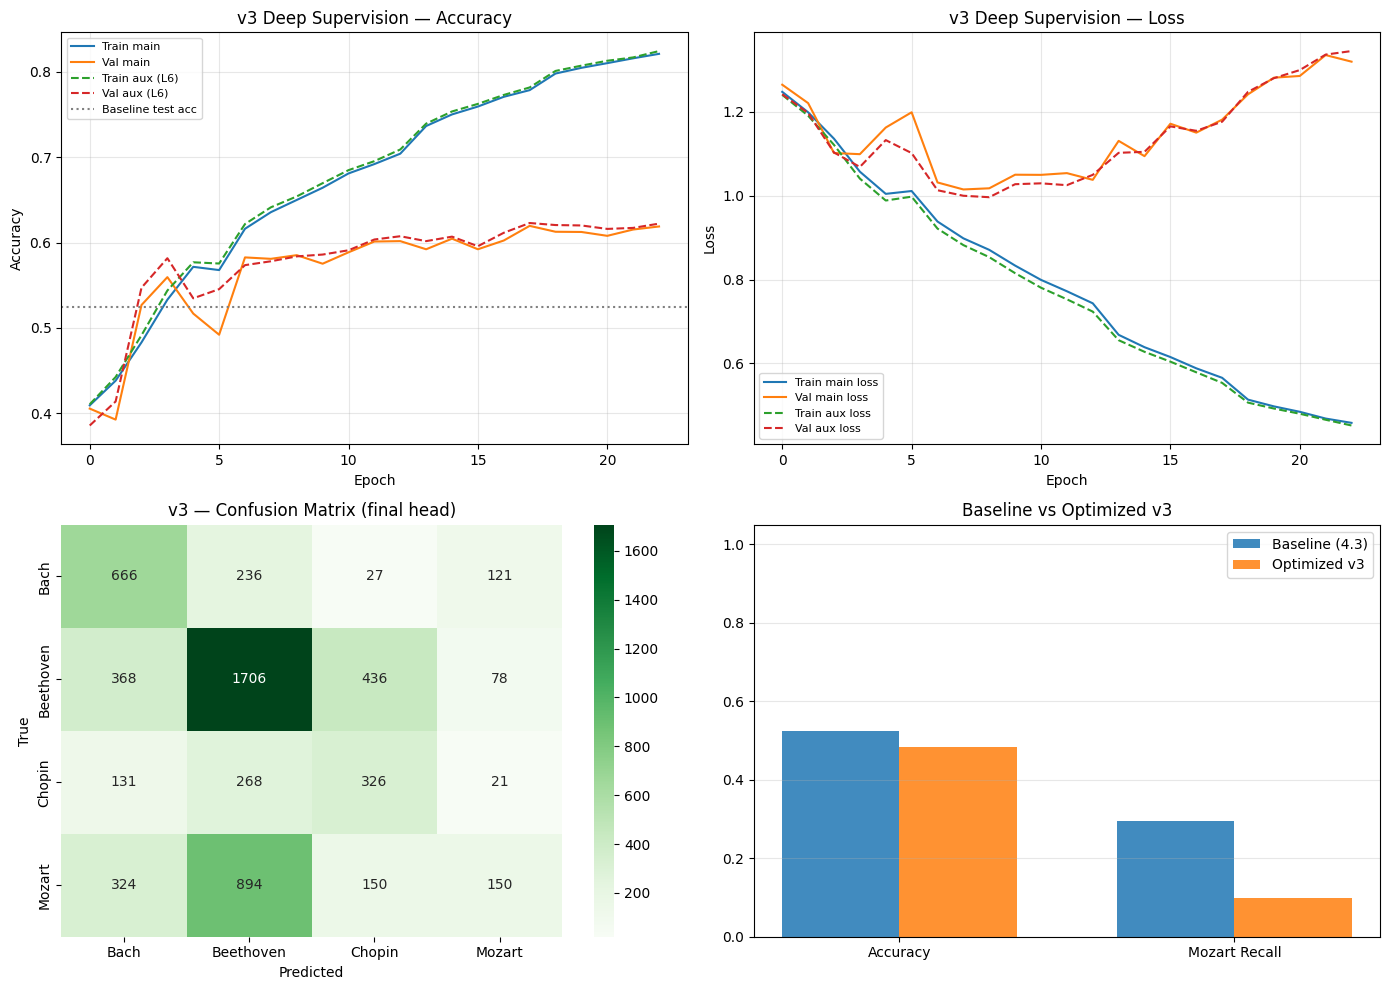


[OK] Optimized v3 model saved to: models/transformer_optimized_v3.keras

SECTION 7 COMPLETE (v3 — Deep Supervision)
Architecture: 12 blocks, aux @ Layer 6
Final Accuracy: 48.25% (baseline 52.41%, Δ -4.15%)
Aux Accuracy: 47.87% (Layer 6 head)
Mozart Recall: 0.0988 (baseline 0.2951, Δ -0.1963)


In [9]:
# Transformer Model Optimization (Section 7) — v3 Deep Supervision
# Goal: beat Section 6.3 baseline (54.21%) with a 12-block Transformer
#       + auxiliary head at intermediate Layer 6/12
# + auxiliary head at intermediate Layer 6/12

print("=" * 80)
print("7. TRANSFORMER MODEL OPTIMIZATION (v3 — Deep Supervision)")
print("=" * 80)

composer_names = ["Bach", "Beethoven", "Chopin", "Mozart"]
NUM_CLASSES = 4
SEQ_LENGTH = X_train.shape[1]
INPUT_DIM = X_train.shape[2]

np.random.seed(42)
tf.random.set_seed(42)

# ---------------------------------------------------------------------------
# Baseline reference (from Section 4.3)
# ---------------------------------------------------------------------------
if "transformer_baseline" not in globals() or not isinstance(transformer_baseline, dict) or "test_accuracy" not in transformer_baseline:
    # Fallback from Section 6.3 baseline evaluation on the song-level split
    transformer_baseline = {
        "test_accuracy": 0.5421,
        "test_loss": 1.2146,
        "precision_macro": 0.5067,
        "recall_macro": 0.5116,
        "f1_macro": 0.4961,
        "per_class": {
            "Bach": {"recall": 0.7029},
            "Beethoven": {"recall": 0.6897},
            "Chopin": {"recall": 0.4035},
            "Mozart": {"recall": 0.2503},
        },
    }

print("\nBaseline (Section 6.3 evaluation):")
print(f"Accuracy: {transformer_baseline['test_accuracy']*100:.2f}%")
print(f"Mozart recall: {transformer_baseline['per_class']['Mozart']['recall']:.2f}")

# ---------------------------------------------------------------------------
# Soft balanced class weights (no aggressive Mozart boost — that hurt v1)
# ---------------------------------------------------------------------------
classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=np.asarray(y_train).ravel())
class_weight_dict = {int(c): float(0.5 * w + 0.5 * 1.0) for c, w in zip(classes, cw)}

print("\nClass weights (v3 — softened balanced):")
for i, name in enumerate(composer_names):
    print(f"{name:12s}: {class_weight_dict[i]:.3f}")

# ---------------------------------------------------------------------------
# Optimized hyperparameters v3 — Deep Supervision
# 12 Transformer blocks; auxiliary head after block 6; final head after block 12
# ---------------------------------------------------------------------------
OPT_CONFIG = {
    "d_model": 128,
    "num_heads": 8,
    "ff_dim": 512,
    "num_blocks": 12, # deep stack
    "aux_block": 6, # deep supervision at Layer 6/12
    "aux_loss_weight": 0.4, # λ in L = L_final + λ * L_aux
    "dropout": 0.20,
    "learning_rate": 1.5e-4,
    "weight_decay": 1e-4,
    "label_smoothing": 0.0,
    "batch_size": 64,
    "epochs": 80,
    "patience": 15,
}

print("\nOptimized hyperparameters (v3 — Deep Supervision):")
for k, v in OPT_CONFIG.items():
    print(f"{k}: {v}")
print("\nDeep supervision:")
print(f"• Total blocks: {OPT_CONFIG['num_blocks']}")
print(f"• Auxiliary head after Layer {OPT_CONFIG['aux_block']}/{OPT_CONFIG['num_blocks']}")
print(f"• Final head after Layer {OPT_CONFIG['num_blocks']}")
print(f"• Loss = L_final + {OPT_CONFIG['aux_loss_weight']} * L_aux")
print("• Inference uses final head only")

# ---------------------------------------------------------------------------
# Model components
# ---------------------------------------------------------------------------
class PositionalEncoding(layers.Layer):
    def __init__(self, sequence_length, d_model, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.d_model = d_model
        position = np.arange(sequence_length)[:, np.newaxis]
        div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
        pe = np.zeros((sequence_length, d_model))
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)
        self.positional_encoding = tf.constant(pe, dtype=tf.float32)

    def call(self, x):
        return x + self.positional_encoding

    def get_config(self):
        config = super().get_config()
        config.update({"sequence_length": self.sequence_length, "d_model": self.d_model})
        return config


class TransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(d_model),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "dropout_rate": self.dropout_rate,
        })
        return config


def classification_head(x, dropout, name_prefix):
    """Shared-style GAP + MLP head for aux / final outputs."""
    h = layers.GlobalAveragePooling1D(name=f"{name_prefix}_gap")(x)
    h = layers.Dropout(dropout, name=f"{name_prefix}_drop1")(h)
    h = layers.Dense(256, activation="relu", name=f"{name_prefix}_fc1")(h)
    h = layers.Dense(128, activation="relu", name=f"{name_prefix}_fc2")(h)
    h = layers.Dropout(dropout, name=f"{name_prefix}_drop2")(h)
    return layers.Dense(NUM_CLASSES, activation="softmax", name=name_prefix)(h)


def build_deep_supervision_transformer(cfg):
    """12-block Transformer with auxiliary head at Layer aux_block (e.g. 6/12)."""
    inputs = layers.Input(shape=(SEQ_LENGTH, INPUT_DIM), name="input_seq")
    x = layers.Dense(cfg["d_model"], name="input_proj")(inputs)
    x = PositionalEncoding(SEQ_LENGTH, cfg["d_model"], name="pos_encoding")(x)

    aux_out = None
    for i in range(1, cfg["num_blocks"] + 1):
        x = TransformerBlock(
            cfg["d_model"], cfg["num_heads"], cfg["ff_dim"], cfg["dropout"],
            name=f"transformer_block_{i}",
        )(x)
        if i == cfg["aux_block"]:
            aux_out = classification_head(x, cfg["dropout"], name_prefix="aux_out")

    main_out = classification_head(x, cfg["dropout"], name_prefix="main_out")

    if aux_out is None:
        raise ValueError(f"aux_block={cfg['aux_block']} must be in 1..{cfg['num_blocks']}")

    # Multi-output: [aux, main] — train both; evaluate with main only
    return keras.Model(
        inputs,
        outputs={"aux_out": aux_out, "main_out": main_out},
        name="transformer_deep_supervision_v3",
    )


transformer_optimized = build_deep_supervision_transformer(OPT_CONFIG)

# One-hot labels (needed for multi-output + optional label smoothing)
y_train_oh = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_dev_oh = keras.utils.to_categorical(y_dev, NUM_CLASSES)
y_test_oh = keras.utils.to_categorical(y_test, NUM_CLASSES)

loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=OPT_CONFIG["label_smoothing"])
transformer_optimized.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=OPT_CONFIG["learning_rate"],
        weight_decay=OPT_CONFIG["weight_decay"],
    ),
    loss={"aux_out": loss_fn, "main_out": loss_fn},
    loss_weights={"aux_out": OPT_CONFIG["aux_loss_weight"], "main_out": 1.0},
    metrics={"aux_out": ["accuracy"], "main_out": ["accuracy"]},
)

print("\n[OK] Deep-supervision Transformer (v3) built")
print(f"Outputs: {list(transformer_optimized.output_names)}")
transformer_optimized.summary()

callbacks_opt = [
    keras.callbacks.EarlyStopping(
        monitor="val_main_out_loss",
        mode="min",
        patience=OPT_CONFIG["patience"],
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_main_out_loss",
        mode="min",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1,
    ),
]

# Multi-output Keras models: class_weight/sample_weight are unreliable — skip them for v3.
print("\n" + "-" * 80)
print("Training optimized Transformer (v3 — Deep Supervision)...")
print("-" * 80)
print("Note: class_weight/sample_weight disabled for multi-output compatibility")

t0 = time.time()
history_opt = transformer_optimized.fit(
    X_train,
    {"aux_out": y_train_oh, "main_out": y_train_oh},
    batch_size=OPT_CONFIG["batch_size"],
    epochs=OPT_CONFIG["epochs"],
    validation_data=(X_dev, {"aux_out": y_dev_oh, "main_out": y_dev_oh}),
    callbacks=callbacks_opt,
    verbose=1,
)
train_minutes = (time.time() - t0) / 60.0

# ---------------------------------------------------------------------------
# Evaluate — use FINAL (main) head only
# ---------------------------------------------------------------------------
print("\n" + "=" * 80)
print("OPTIMIZED MODEL v3 — TEST EVALUATION (final head / Layer 12)")
print("=" * 80)

eval_results = transformer_optimized.evaluate(
    X_test, {"aux_out": y_test_oh, "main_out": y_test_oh}, verbose=0, return_dict=True
)
print("Keras evaluate:", {k: float(v) for k, v in eval_results.items()})

preds = transformer_optimized.predict(X_test, verbose=0)
# dict outputs -> dict of arrays; list fallback for older Keras
if isinstance(preds, dict):
    y_prob_aux, y_prob_opt = preds["aux_out"], preds["main_out"]
else:
    y_prob_aux, y_prob_opt = preds[0], preds[1]
y_pred_opt = np.argmax(y_prob_opt, axis=1)
y_pred_aux = np.argmax(y_prob_aux, axis=1)
y_true = np.asarray(y_test).ravel()

opt_accuracy = accuracy_score(y_true, y_pred_opt)
opt_precision = precision_score(y_true, y_pred_opt, average="macro", zero_division=0)
opt_recall = recall_score(y_true, y_pred_opt, average="macro", zero_division=0)
opt_f1 = f1_score(y_true, y_pred_opt, average="macro", zero_division=0)
mozart_recall = recall_score(y_true, y_pred_opt, labels=[3], average="macro", zero_division=0)
aux_accuracy = accuracy_score(y_true, y_pred_aux)
opt_loss = float(eval_results.get("main_out_loss", eval_results.get("loss", np.nan)))

print(f"Final-head Test Accuracy: {opt_accuracy:.4f} ({opt_accuracy*100:.2f}%)")
print(f"Aux-head Test Accuracy: {aux_accuracy:.4f} ({aux_accuracy*100:.2f}%) [Layer {OPT_CONFIG['aux_block']}]")
print(f"Main loss: {opt_loss:.4f}")
print(f"Precision (macro): {opt_precision:.4f}")
print(f"Recall (macro): {opt_recall:.4f}")
print(f"F1 (macro): {opt_f1:.4f}")
print(f"Mozart Recall: {mozart_recall:.4f}")
print(f"Training time: {train_minutes:.2f} min")

print("\n" + classification_report(y_true, y_pred_opt, target_names=composer_names, digits=4, zero_division=0))

cm_opt = confusion_matrix(y_true, y_pred_opt)
print("Confusion Matrix (final head):\n", cm_opt)

# ---------------------------------------------------------------------------
# Baseline vs Optimized comparison
# ---------------------------------------------------------------------------
base_acc = transformer_baseline["test_accuracy"]
base_mozart = transformer_baseline["per_class"]["Mozart"]["recall"]
delta_acc = opt_accuracy - base_acc
delta_mozart = mozart_recall - base_mozart

print("\n" + "=" * 80)
print("BASELINE vs OPTIMIZED (v3 Deep Supervision)")
print("=" * 80)
print(f"{'Metric':<22} {'Baseline':>12} {'Optimized':>12} {'Delta':>12}")
print(f"{'-'*22} {'-'*12} {'-'*12} {'-'*12}")
print(f"{'Accuracy':<22} {base_acc*100:>11.2f}% {opt_accuracy*100:>11.2f}% {delta_acc*100:>+11.2f}%")
print(f"{'Mozart Recall':<22} {base_mozart:>12.4f} {mozart_recall:>12.4f} {delta_mozart:>+12.4f}")
base_p = transformer_baseline.get("precision_macro", 0.5067)
base_r = transformer_baseline.get("recall_macro", 0.5116)
base_f = transformer_baseline.get("f1_macro", 0.4961)
print(f"{'Macro Precision':<22} {base_p:>12.4f} {opt_precision:>12.4f}")
print(f"{'Macro Recall':<22} {base_r:>12.4f} {opt_recall:>12.4f}")
print(f"{'Macro F1':<22} {base_f:>12.4f} {opt_f1:>12.4f}")
print(f"{'Aux Acc (L6)':<22} {'—':>12} {aux_accuracy:>12.4f}")
print("=" * 80)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Main-head accuracy curves
main_acc_key = "main_out_accuracy" if "main_out_accuracy" in history_opt.history else "accuracy"
val_main_acc_key = "val_main_out_accuracy" if "val_main_out_accuracy" in history_opt.history else "val_accuracy"
axes[0, 0].plot(history_opt.history.get(main_acc_key, []), label="Train main")
axes[0, 0].plot(history_opt.history.get(val_main_acc_key, []), label="Val main")
if "aux_out_accuracy" in history_opt.history:
    axes[0, 0].plot(history_opt.history["aux_out_accuracy"], label="Train aux (L6)", linestyle="--")
    axes[0, 0].plot(history_opt.history["val_aux_out_accuracy"], label="Val aux (L6)", linestyle="--")
axes[0, 0].axhline(base_acc, color="gray", linestyle=":", label="Baseline test acc")
axes[0, 0].set_title("v3 Deep Supervision — Accuracy")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

loss_key = "main_out_loss" if "main_out_loss" in history_opt.history else "loss"
val_loss_key = "val_main_out_loss" if "val_main_out_loss" in history_opt.history else "val_loss"
axes[0, 1].plot(history_opt.history.get(loss_key, []), label="Train main loss")
axes[0, 1].plot(history_opt.history.get(val_loss_key, []), label="Val main loss")
if "aux_out_loss" in history_opt.history:
    axes[0, 1].plot(history_opt.history["aux_out_loss"], label="Train aux loss", linestyle="--")
    axes[0, 1].plot(history_opt.history["val_aux_out_loss"], label="Val aux loss", linestyle="--")
axes[0, 1].set_title("v3 Deep Supervision — Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

sns.heatmap(
    cm_opt, annot=True, fmt="d", cmap="Greens",
    xticklabels=composer_names, yticklabels=composer_names, ax=axes[1, 0],
)
axes[1, 0].set_title("v3 — Confusion Matrix (final head)")
axes[1, 0].set_xlabel("Predicted")
axes[1, 0].set_ylabel("True")

metrics = ["Accuracy", "Mozart Recall"]
base_vals = [base_acc, base_mozart]
opt_vals = [opt_accuracy, mozart_recall]
x = np.arange(len(metrics))
width = 0.35
axes[1, 1].bar(x - width / 2, base_vals, width, label="Baseline (4.3)", alpha=0.85)
axes[1, 1].bar(x + width / 2, opt_vals, width, label="Optimized v3", alpha=0.85)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics)
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].set_title("Baseline vs Optimized v3")
axes[1, 1].legend()
axes[1, 1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Save optimized model
import os

save_candidates = [
    "models/transformer_optimized_v3.keras",
    "/content/drive/MyDrive/aai-511-final-project-group1/models/transformer_optimized_v3.keras",
    "/Workspace/Users/mzamaniturk@sandiego.edu/aai-511-final-project-group1/models/transformer_optimized_v3.keras",
]
saved = False
for path_try in save_candidates:
    try:
        os.makedirs(os.path.dirname(path_try) or ".", exist_ok=True)
        transformer_optimized.save(path_try)
        print(f"\n[OK] Optimized v3 model saved to: {path_try}")
        saved = True
        break
    except Exception:
        continue
if not saved:
    print("\nWARNING: Could not save model to disk. Model remains in memory as `transformer_optimized`.")

print("\n" + "=" * 80)
print("SECTION 7 COMPLETE (v3 — Deep Supervision)")
print("=" * 80)
print(f"Architecture: {OPT_CONFIG['num_blocks']} blocks, aux @ Layer {OPT_CONFIG['aux_block']}")
print(f"Final Accuracy: {opt_accuracy*100:.2f}% (baseline {base_acc*100:.2f}%, Δ {delta_acc*100:+.2f}%)")
print(f"Aux Accuracy: {aux_accuracy*100:.2f}% (Layer {OPT_CONFIG['aux_block']} head)")
print(f"Mozart Recall: {mozart_recall:.4f} (baseline {base_mozart:.4f}, Δ {delta_mozart:+.4f})")
print("=" * 80)


#### 7.3.v4

7. TRANSFORMER MODEL OPTIMIZATION (v4 — Deep Supervision)

Baseline (Section 6.3 evaluation):
Accuracy: 52.41%
Mozart recall: 0.30

Class weights (v4 — softened balanced):
Bach        : 1.100
Beethoven   : 0.814
Chopin      : 1.111
Mozart      : 1.162

Optimized hyperparameters (v4 — Deep Supervision):
d_model: 128
num_heads: 8
ff_dim: 512
num_blocks: 5
aux_block: 3
aux_loss_weight: 0.4
dropout: 0.2
learning_rate: 0.00015
weight_decay: 0.0001
label_smoothing: 0.0
batch_size: 64
epochs: 80
patience: 15

Deep supervision:
• Total blocks: 5
• Auxiliary head after Layer 3/5
• Final head after Layer 5
• Loss = L_final + 0.4 * L_aux
• Inference uses final head only

[OK] Deep-supervision Transformer (v4) built
Outputs: ['aux_out', 'main_out']


Model: "transformer_deep_supervision_v4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_seq           │ (None, 100, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_proj (Dense)  │ (None, 100, 128)  │        512 │ input_seq[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_encoding        │ (None, 100, 128)  │          0 │ input_proj[0][0]  │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_1 │ (None, 100, 128)  │    198,272 │ pos_encoding[0][… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_2 │ (None, 100, 128)  │    198,272 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_3 │ (None, 100, 128)  │    198,272 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_4 │ (None, 100, 128)  │    198,272 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_5 │ (None, 100, 128)  │    198,272 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aux_out_gap         │ (None, 128)       │          0 │ transformer_bloc… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ main_out_gap        │ (None, 128)       │          0 │ transformer_bloc… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aux_out_drop1       │ (None, 128)       │          0 │ aux_out_gap[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ main_out_drop1      │ (None, 128)       │          0 │ main_out_gap[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aux_out_fc1 (Dense) │ (None, 256)       │     33,024 │ aux_out_drop1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ main_out_fc1        │ (None, 256)       │     33,024 │ main_out_drop1[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aux_out_fc2 (Dense) │ (None, 128)       │     32,896 │ aux_out_fc1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ main_out_fc2        │ (None, 128)       │     32,896 │ main_out_fc1[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aux_out_drop2       │ (None, 128)       │          0 │ aux_out_fc2[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ main_out_drop2      │ (None, 128)       │          0 │ main_out_fc2[0][

 Total params: 1,124,744 (4.29 MB)

 Trainable params: 1,124,744 (4.29 MB)

 Non-trainable params: 0 (0.00 B)


--------------------------------------------------------------------------------
Training optimized Transformer (v4 — Deep Supervision)...
--------------------------------------------------------------------------------
Note: class_weight/sample_weight disabled for multi-output compatibility
Epoch 1/80
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 70s 32ms/step - aux_out_accuracy: 0.4137 - aux_out_loss: 1.2316 - loss: 1.7249 - main_out_accuracy: 0.4133 - main_out_loss: 1.2324 - val_aux_out_accuracy: 0.4606 - val_aux_out_loss: 1.1446 - val_loss: 1.6301 - val_main_out_accuracy: 0.4277 - val_main_out_loss: 1.1707 - learning_rate: 1.5000e-04
Epoch 2/80
1074/1074 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - aux_out_accuracy: 0.4677 - aux_out_loss: 1.1610 - loss: 1.6295 - main_out_accuracy: 0.4651 - main_out_loss: 1.1654 - val_aux_out_accuracy: 0.4492 - val_aux_out_loss: 1.2042 - val_loss: 1.6804 - val_main_out_accuracy: 0.4606 - val_main_out_loss: 1.1957 - learning_rate: 1.5000e-04
Epoch 3/80
1074/1074 ━━━━━━━━━━━

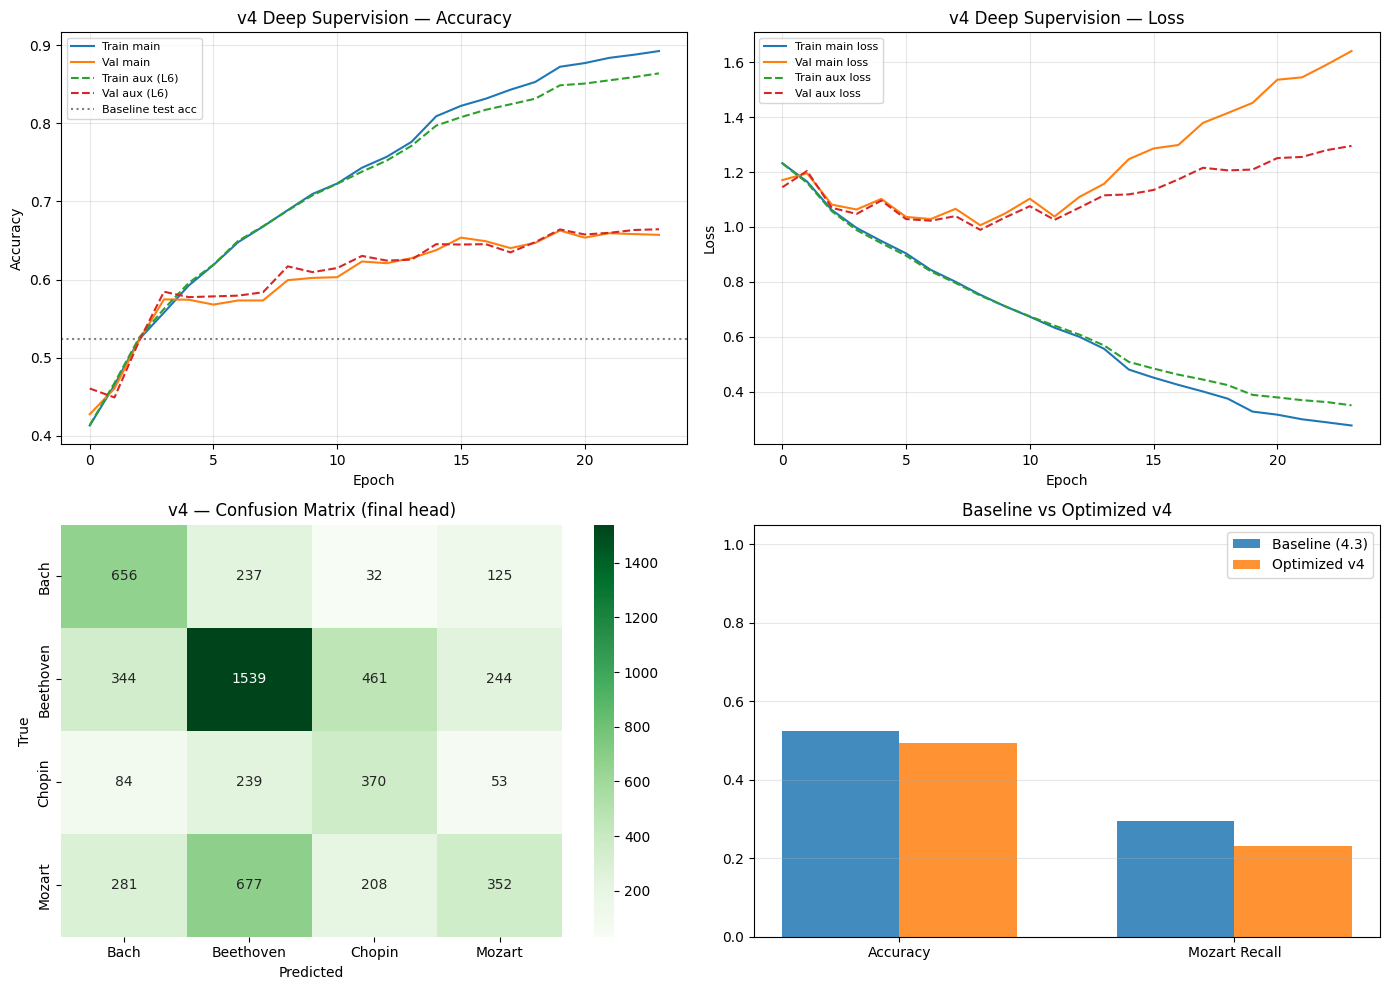


[OK] Optimized v4 model saved to: models/transformer_optimized_v4.keras

SECTION 7 COMPLETE (v4 — Deep Supervision)
Architecture: 5 blocks, aux @ Layer 3
Final Accuracy: 49.42% (baseline 52.41%, Δ -2.98%)
Aux Accuracy: 50.53% (Layer 3 head)
Mozart Recall: 0.2319 (baseline 0.2951, Δ -0.0632)


In [10]:
# Transformer Model Optimization (Section 7) — v4 Deep Supervision
# Goal: beat Section 6.3 baseline (54.21%) with a 5-block Transformer
#       + auxiliary head at intermediate Layer 3/5
# + auxiliary head at intermediate Layer 3/5

print("=" * 80)
print("7. TRANSFORMER MODEL OPTIMIZATION (v4 — Deep Supervision)")
print("=" * 80)

composer_names = ["Bach", "Beethoven", "Chopin", "Mozart"]
NUM_CLASSES = 4
SEQ_LENGTH = X_train.shape[1]
INPUT_DIM = X_train.shape[2]

np.random.seed(42)
tf.random.set_seed(42)

# ---------------------------------------------------------------------------
# Baseline reference (from Section 4.3)
# ---------------------------------------------------------------------------
if "transformer_baseline" not in globals() or not isinstance(transformer_baseline, dict) or "test_accuracy" not in transformer_baseline:
    # Fallback from Section 6.3 baseline evaluation on the song-level split
    transformer_baseline = {
        "test_accuracy": 0.5421,
        "test_loss": 1.2146,
        "precision_macro": 0.5067,
        "recall_macro": 0.5116,
        "f1_macro": 0.4961,
        "per_class": {
            "Bach": {"recall": 0.7029},
            "Beethoven": {"recall": 0.6897},
            "Chopin": {"recall": 0.4035},
            "Mozart": {"recall": 0.2503},
        },
    }

print("\nBaseline (Section 6.3 evaluation):")
print(f"Accuracy: {transformer_baseline['test_accuracy']*100:.2f}%")
print(f"Mozart recall: {transformer_baseline['per_class']['Mozart']['recall']:.2f}")

# ---------------------------------------------------------------------------
# Soft balanced class weights (no aggressive Mozart boost — that hurt v1)
# ---------------------------------------------------------------------------
classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=np.asarray(y_train).ravel())
class_weight_dict = {int(c): float(0.5 * w + 0.5 * 1.0) for c, w in zip(classes, cw)}

print("\nClass weights (v4 — softened balanced):")
for i, name in enumerate(composer_names):
    print(f"{name:12s}: {class_weight_dict[i]:.3f}")

# ---------------------------------------------------------------------------
# Optimized hyperparameters v4 — Deep Supervision
# 5 Transformer blocks; auxiliary head after block 3; final head after block 5
# ---------------------------------------------------------------------------
OPT_CONFIG = {
    "d_model": 128,
    "num_heads": 8,
    "ff_dim": 512,
    "num_blocks": 5, # transformer depth
    "aux_block": 3, # deep supervision at Layer 3/5
    "aux_loss_weight": 0.4, # λ in L = L_final + λ * L_aux
    "dropout": 0.20,
    "learning_rate": 1.5e-4,
    "weight_decay": 1e-4,
    "label_smoothing": 0.0,
    "batch_size": 64,
    "epochs": 80,
    "patience": 15,
}

print("\nOptimized hyperparameters (v4 — Deep Supervision):")
for k, v in OPT_CONFIG.items():
    print(f"{k}: {v}")
print("\nDeep supervision:")
print(f"• Total blocks: {OPT_CONFIG['num_blocks']}")
print(f"• Auxiliary head after Layer {OPT_CONFIG['aux_block']}/{OPT_CONFIG['num_blocks']}")
print(f"• Final head after Layer {OPT_CONFIG['num_blocks']}")
print(f"• Loss = L_final + {OPT_CONFIG['aux_loss_weight']} * L_aux")
print("• Inference uses final head only")

# ---------------------------------------------------------------------------
# Model components
# ---------------------------------------------------------------------------
class PositionalEncoding(layers.Layer):
    def __init__(self, sequence_length, d_model, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.d_model = d_model
        position = np.arange(sequence_length)[:, np.newaxis]
        div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
        pe = np.zeros((sequence_length, d_model))
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)
        self.positional_encoding = tf.constant(pe, dtype=tf.float32)

    def call(self, x):
        return x + self.positional_encoding

    def get_config(self):
        config = super().get_config()
        config.update({"sequence_length": self.sequence_length, "d_model": self.d_model})
        return config


class TransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(d_model),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "dropout_rate": self.dropout_rate,
        })
        return config


def classification_head(x, dropout, name_prefix):
    """Shared-style GAP + MLP head for aux / final outputs."""
    h = layers.GlobalAveragePooling1D(name=f"{name_prefix}_gap")(x)
    h = layers.Dropout(dropout, name=f"{name_prefix}_drop1")(h)
    h = layers.Dense(256, activation="relu", name=f"{name_prefix}_fc1")(h)
    h = layers.Dense(128, activation="relu", name=f"{name_prefix}_fc2")(h)
    h = layers.Dropout(dropout, name=f"{name_prefix}_drop2")(h)
    return layers.Dense(NUM_CLASSES, activation="softmax", name=name_prefix)(h)


def build_deep_supervision_transformer(cfg):
    """5-block Transformer with auxiliary head at Layer aux_block (e.g. 3/5)."""
    inputs = layers.Input(shape=(SEQ_LENGTH, INPUT_DIM), name="input_seq")
    x = layers.Dense(cfg["d_model"], name="input_proj")(inputs)
    x = PositionalEncoding(SEQ_LENGTH, cfg["d_model"], name="pos_encoding")(x)

    aux_out = None
    for i in range(1, cfg["num_blocks"] + 1):
        x = TransformerBlock(
            cfg["d_model"], cfg["num_heads"], cfg["ff_dim"], cfg["dropout"],
            name=f"transformer_block_{i}",
        )(x)
        if i == cfg["aux_block"]:
            aux_out = classification_head(x, cfg["dropout"], name_prefix="aux_out")

    main_out = classification_head(x, cfg["dropout"], name_prefix="main_out")

    if aux_out is None:
        raise ValueError(f"aux_block={cfg['aux_block']} must be in 1..{cfg['num_blocks']}")

    # Multi-output: [aux, main] — train both; evaluate with main only
    return keras.Model(
        inputs,
        outputs={"aux_out": aux_out, "main_out": main_out},
        name="transformer_deep_supervision_v4",
    )


transformer_optimized = build_deep_supervision_transformer(OPT_CONFIG)

# One-hot labels (needed for multi-output + optional label smoothing)
y_train_oh = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_dev_oh = keras.utils.to_categorical(y_dev, NUM_CLASSES)
y_test_oh = keras.utils.to_categorical(y_test, NUM_CLASSES)

loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=OPT_CONFIG["label_smoothing"])
transformer_optimized.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=OPT_CONFIG["learning_rate"],
        weight_decay=OPT_CONFIG["weight_decay"],
    ),
    loss={"aux_out": loss_fn, "main_out": loss_fn},
    loss_weights={"aux_out": OPT_CONFIG["aux_loss_weight"], "main_out": 1.0},
    metrics={"aux_out": ["accuracy"], "main_out": ["accuracy"]},
)

print("\n[OK] Deep-supervision Transformer (v4) built")
print(f"Outputs: {list(transformer_optimized.output_names)}")
transformer_optimized.summary()

callbacks_opt = [
    keras.callbacks.EarlyStopping(
        monitor="val_main_out_loss",
        mode="min",
        patience=OPT_CONFIG["patience"],
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_main_out_loss",
        mode="min",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1,
    ),
]

# Multi-output Keras models: class_weight/sample_weight are unreliable — skip them for v4.
print("\n" + "-" * 80)
print("Training optimized Transformer (v4 — Deep Supervision)...")
print("-" * 80)
print("Note: class_weight/sample_weight disabled for multi-output compatibility")

t0 = time.time()
history_opt = transformer_optimized.fit(
    X_train,
    {"aux_out": y_train_oh, "main_out": y_train_oh},
    batch_size=OPT_CONFIG["batch_size"],
    epochs=OPT_CONFIG["epochs"],
    validation_data=(X_dev, {"aux_out": y_dev_oh, "main_out": y_dev_oh}),
    callbacks=callbacks_opt,
    verbose=1,
)
train_minutes = (time.time() - t0) / 60.0

# ---------------------------------------------------------------------------
# Evaluate — use FINAL (main) head only
# ---------------------------------------------------------------------------
print("\n" + "=" * 80)
print("OPTIMIZED MODEL v4 — TEST EVALUATION (final head / Layer 5)")
print("=" * 80)

eval_results = transformer_optimized.evaluate(
    X_test, {"aux_out": y_test_oh, "main_out": y_test_oh}, verbose=0, return_dict=True
)
print("Keras evaluate:", {k: float(v) for k, v in eval_results.items()})

preds = transformer_optimized.predict(X_test, verbose=0)
# dict outputs -> dict of arrays; list fallback for older Keras
if isinstance(preds, dict):
    y_prob_aux, y_prob_opt = preds["aux_out"], preds["main_out"]
else:
    y_prob_aux, y_prob_opt = preds[0], preds[1]
y_pred_opt = np.argmax(y_prob_opt, axis=1)
y_pred_aux = np.argmax(y_prob_aux, axis=1)
y_true = np.asarray(y_test).ravel()

opt_accuracy = accuracy_score(y_true, y_pred_opt)
opt_precision = precision_score(y_true, y_pred_opt, average="macro", zero_division=0)
opt_recall = recall_score(y_true, y_pred_opt, average="macro", zero_division=0)
opt_f1 = f1_score(y_true, y_pred_opt, average="macro", zero_division=0)
mozart_recall = recall_score(y_true, y_pred_opt, labels=[3], average="macro", zero_division=0)
aux_accuracy = accuracy_score(y_true, y_pred_aux)
opt_loss = float(eval_results.get("main_out_loss", eval_results.get("loss", np.nan)))

print(f"Final-head Test Accuracy: {opt_accuracy:.4f} ({opt_accuracy*100:.2f}%)")
print(f"Aux-head Test Accuracy: {aux_accuracy:.4f} ({aux_accuracy*100:.2f}%) [Layer {OPT_CONFIG['aux_block']}]")
print(f"Main loss: {opt_loss:.4f}")
print(f"Precision (macro): {opt_precision:.4f}")
print(f"Recall (macro): {opt_recall:.4f}")
print(f"F1 (macro): {opt_f1:.4f}")
print(f"Mozart Recall: {mozart_recall:.4f}")
print(f"Training time: {train_minutes:.2f} min")

print("\n" + classification_report(y_true, y_pred_opt, target_names=composer_names, digits=4, zero_division=0))

cm_opt = confusion_matrix(y_true, y_pred_opt)
print("Confusion Matrix (final head):\n", cm_opt)

# ---------------------------------------------------------------------------
# Baseline vs Optimized comparison
# ---------------------------------------------------------------------------
base_acc = transformer_baseline["test_accuracy"]
base_mozart = transformer_baseline["per_class"]["Mozart"]["recall"]
delta_acc = opt_accuracy - base_acc
delta_mozart = mozart_recall - base_mozart

print("\n" + "=" * 80)
print("BASELINE vs OPTIMIZED (v4 Deep Supervision)")
print("=" * 80)
print(f"{'Metric':<22} {'Baseline':>12} {'Optimized':>12} {'Delta':>12}")
print(f"{'-'*22} {'-'*12} {'-'*12} {'-'*12}")
print(f"{'Accuracy':<22} {base_acc*100:>11.2f}% {opt_accuracy*100:>11.2f}% {delta_acc*100:>+11.2f}%")
print(f"{'Mozart Recall':<22} {base_mozart:>12.4f} {mozart_recall:>12.4f} {delta_mozart:>+12.4f}")
base_p = transformer_baseline.get("precision_macro", 0.5067)
base_r = transformer_baseline.get("recall_macro", 0.5116)
base_f = transformer_baseline.get("f1_macro", 0.4961)
print(f"{'Macro Precision':<22} {base_p:>12.4f} {opt_precision:>12.4f}")
print(f"{'Macro Recall':<22} {base_r:>12.4f} {opt_recall:>12.4f}")
print(f"{'Macro F1':<22} {base_f:>12.4f} {opt_f1:>12.4f}")
print(f"{'Aux Acc (L6)':<22} {'—':>12} {aux_accuracy:>12.4f}")
print("=" * 80)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Main-head accuracy curves
main_acc_key = "main_out_accuracy" if "main_out_accuracy" in history_opt.history else "accuracy"
val_main_acc_key = "val_main_out_accuracy" if "val_main_out_accuracy" in history_opt.history else "val_accuracy"
axes[0, 0].plot(history_opt.history.get(main_acc_key, []), label="Train main")
axes[0, 0].plot(history_opt.history.get(val_main_acc_key, []), label="Val main")
if "aux_out_accuracy" in history_opt.history:
    axes[0, 0].plot(history_opt.history["aux_out_accuracy"], label="Train aux (L6)", linestyle="--")
    axes[0, 0].plot(history_opt.history["val_aux_out_accuracy"], label="Val aux (L6)", linestyle="--")
axes[0, 0].axhline(base_acc, color="gray", linestyle=":", label="Baseline test acc")
axes[0, 0].set_title("v4 Deep Supervision — Accuracy")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

loss_key = "main_out_loss" if "main_out_loss" in history_opt.history else "loss"
val_loss_key = "val_main_out_loss" if "val_main_out_loss" in history_opt.history else "val_loss"
axes[0, 1].plot(history_opt.history.get(loss_key, []), label="Train main loss")
axes[0, 1].plot(history_opt.history.get(val_loss_key, []), label="Val main loss")
if "aux_out_loss" in history_opt.history:
    axes[0, 1].plot(history_opt.history["aux_out_loss"], label="Train aux loss", linestyle="--")
    axes[0, 1].plot(history_opt.history["val_aux_out_loss"], label="Val aux loss", linestyle="--")
axes[0, 1].set_title("v4 Deep Supervision — Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

sns.heatmap(
    cm_opt, annot=True, fmt="d", cmap="Greens",
    xticklabels=composer_names, yticklabels=composer_names, ax=axes[1, 0],
)
axes[1, 0].set_title("v4 — Confusion Matrix (final head)")
axes[1, 0].set_xlabel("Predicted")
axes[1, 0].set_ylabel("True")

metrics = ["Accuracy", "Mozart Recall"]
base_vals = [base_acc, base_mozart]
opt_vals = [opt_accuracy, mozart_recall]
x = np.arange(len(metrics))
width = 0.35
axes[1, 1].bar(x - width / 2, base_vals, width, label="Baseline (4.3)", alpha=0.85)
axes[1, 1].bar(x + width / 2, opt_vals, width, label="Optimized v4", alpha=0.85)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics)
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].set_title("Baseline vs Optimized v4")
axes[1, 1].legend()
axes[1, 1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Save optimized model
import os

save_candidates = [
    "models/transformer_optimized_v4.keras",
    "/content/drive/MyDrive/aai-511-final-project-group1/models/transformer_optimized_v4.keras",
    "/Workspace/Users/mzamaniturk@sandiego.edu/aai-511-final-project-group1/models/transformer_optimized_v4.keras",
]
saved = False
for path_try in save_candidates:
    try:
        os.makedirs(os.path.dirname(path_try) or ".", exist_ok=True)
        transformer_optimized.save(path_try)
        print(f"\n[OK] Optimized v4 model saved to: {path_try}")
        saved = True
        break
    except Exception:
        continue
if not saved:
    print("\nWARNING: Could not save model to disk. Model remains in memory as `transformer_optimized`.")

print("\n" + "=" * 80)
print("SECTION 7 COMPLETE (v4 — Deep Supervision)")
print("=" * 80)
print(f"Architecture: {OPT_CONFIG['num_blocks']} blocks, aux @ Layer {OPT_CONFIG['aux_block']}")
print(f"Final Accuracy: {opt_accuracy*100:.2f}% (baseline {base_acc*100:.2f}%, Δ {delta_acc*100:+.2f}%)")
print(f"Aux Accuracy: {aux_accuracy*100:.2f}% (Layer {OPT_CONFIG['aux_block']} head)")
print(f"Mozart Recall: {mozart_recall:.4f} (baseline {base_mozart:.4f}, Δ {delta_mozart:+.4f})")
print("=" * 80)
